In [1]:
import os, random, glob
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
import torchvision.transforms.functional as TF
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


In [2]:
import os
!ls -R /kaggle/input/datasets/shuvoalok/cityscapes | head -n 20

/kaggle/input/datasets/shuvoalok/cityscapes:
train
val

/kaggle/input/datasets/shuvoalok/cityscapes/train:
img
label

/kaggle/input/datasets/shuvoalok/cityscapes/train/img:
train1000.png
train1001.png
train1002.png
train1003.png
train1004.png
train1005.png
train1006.png
train1007.png
train1008.png
train1009.png
train100.png
ls: write error: Broken pipe


In [3]:
# ── Dataset paths (shuvoalok/cityscapes on Kaggle) ───────────────────────────
# Structure:
#   /kaggle/input/cityscapes/
#     leftImg8bit/train/<city>/*_leftImg8bit.png
#     leftImg8bit/val/<city>/*_leftImg8bit.png
#     gtFine/train/<city>/*_gtFine_labelIds.png
#     gtFine/val/<city>/*_gtFine_labelIds.png
DATA_ROOT    = '/kaggle/input/datasets/shuvoalok/cityscapes'


IMG_SIZE     = (256, 512)   # (H, W)  — standard Cityscapes crop ratio
NUM_CLASSES  = 19
IGNORE_INDEX = 255

# Official Cityscapes trainId mapping
# gtFine_labelIds.png uses raw label IDs (0-33+) → remap to 0-18 train IDs
# Ids not in the map are set to IGNORE_INDEX
LABEL_TO_TRAINID = {
     7: 0,   # road
     8: 1,   # sidewalk
    11: 2,   # building
    12: 3,   # wall
    13: 4,   # fence
    17: 5,   # pole
    19: 6,   # traffic light
    20: 7,   # traffic sign
    21: 8,   # vegetation
    22: 9,   # terrain
    23:10,   # sky
    24:11,   # person
    25:12,   # rider
    26:13,   # car
    27:14,   # truck
    28:15,   # bus
    31:16,   # train
    32:17,   # motorcycle
    33:18,   # bicycle
}

CLASS_NAMES = [
    'road','sidewalk','building','wall','fence','pole',
    'traffic light','traffic sign','vegetation','terrain',
    'sky','person','rider','car','truck','bus',
    'train','motorcycle','bicycle',
]


In [4]:
# Build a 256-element lookup table once for fast numpy remap
_LUT = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for raw_id, train_id in LABEL_TO_TRAINID.items():
    if raw_id < 256:
        _LUT[raw_id] = train_id

def remap_labels(label_img: np.ndarray) -> np.ndarray:
    """Map raw Cityscapes label IDs → 0-18 trainIds (255 = ignore)."""
    return _LUT[label_img.astype(np.uint8)]


In [5]:
class SegmentationAugmentation:
    """
    Joint image+mask augmentations for semantic segmentation.
    All spatial transforms are applied identically to both.
    Colour/noise transforms are applied to the image only.

    Augmentations applied during training:
      Spatial  : RandomHorizontalFlip, RandomResizedCrop, RandomRotation
      Colour   : ColorJitter (brightness, contrast, saturation, hue)
      Noise    : GaussianBlur
      Normalize: ImageNet mean/std
    """

    def __init__(self, img_size: tuple, split: str = 'train'):
        self.img_size = img_size  # (H, W)
        self.split    = split

        # Image-only colour/noise transforms
        self.color_jitter = transforms.ColorJitter(
            brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1
        )
        self.gaussian_blur = transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5))
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )

    def __call__(self, image: Image.Image, mask: Image.Image):
        H, W = self.img_size

        if self.split == 'train':
            # ── 1. Random Horizontal Flip ──────────────────────────────────
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask  = TF.hflip(mask)

            # ── 2. Random Scale + Crop ─────────────────────────────────────
            scale  = random.uniform(0.5, 2.0)
            new_w  = int(W * scale)
            new_h  = int(H * scale)
            image  = TF.resize(image, (new_h, new_w), interpolation=Image.BILINEAR)
            mask   = TF.resize(mask,  (new_h, new_w), interpolation=Image.NEAREST)

            # Pad if needed so crop is always possible
            pad_h  = max(0, H - new_h)
            pad_w  = max(0, W - new_w)
            if pad_h > 0 or pad_w > 0:
                image = TF.pad(image, (0, 0, pad_w, pad_h), fill=0)
                mask  = TF.pad(mask,  (0, 0, pad_w, pad_h), fill=IGNORE_INDEX)

            # Random crop
            i, j, h, w = transforms.RandomCrop.get_params(
                image, output_size=(H, W)
            )
            image = TF.crop(image, i, j, h, w)
            mask  = TF.crop(mask,  i, j, h, w)

            # ── 3. Random Rotation (±10°) ──────────────────────────────────
            if random.random() > 0.5:
                angle = random.uniform(-10, 10)
                image = TF.rotate(image, angle, interpolation=Image.BILINEAR, fill=0)
                mask  = TF.rotate(mask,  angle, interpolation=Image.NEAREST,  fill=IGNORE_INDEX)

            # ── 4. Color Jitter (image only) ───────────────────────────────
            if random.random() > 0.5:
                image = self.color_jitter(image)

            # ── 5. Gaussian Blur (image only) ──────────────────────────────
            if random.random() > 0.3:
                image = self.gaussian_blur(image)

        else:
            # Val / Test: deterministic resize only
            image = TF.resize(image, (H, W), interpolation=Image.BILINEAR)
            mask  = TF.resize(mask,  (H, W), interpolation=Image.NEAREST)

        # ── To tensor + normalize ──────────────────────────────────────────
        image = self.normalize(TF.to_tensor(image))
        mask  = torch.from_numpy(np.array(mask, dtype=np.int64))
        return image, mask


def visualise_augmentations(dataset, n: int = 4):
    """Show n samples with their augmented masks side-by-side."""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    fig, axes = plt.subplots(n, 2, figsize=(10, n * 3))
    indices = random.sample(range(len(dataset)), n)
    for row, idx in enumerate(indices):
        img, mask = dataset[idx]
        img_np = (img.permute(1,2,0).numpy() * std + mean).clip(0,1)
        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title(f'Image #{idx}', fontsize=9)
        axes[row, 0].axis('off')
        axes[row, 1].imshow(mask.numpy(), cmap='tab20', vmin=0, vmax=18)
        axes[row, 1].set_title(f'Mask #{idx}', fontsize=9)
        axes[row, 1].axis('off')
    plt.suptitle('Augmented Samples (Train Split)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('augmentation_preview.png', dpi=100, bbox_inches='tight')
    plt.show()


[train] 2975 image/mask pairs loaded.


/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')


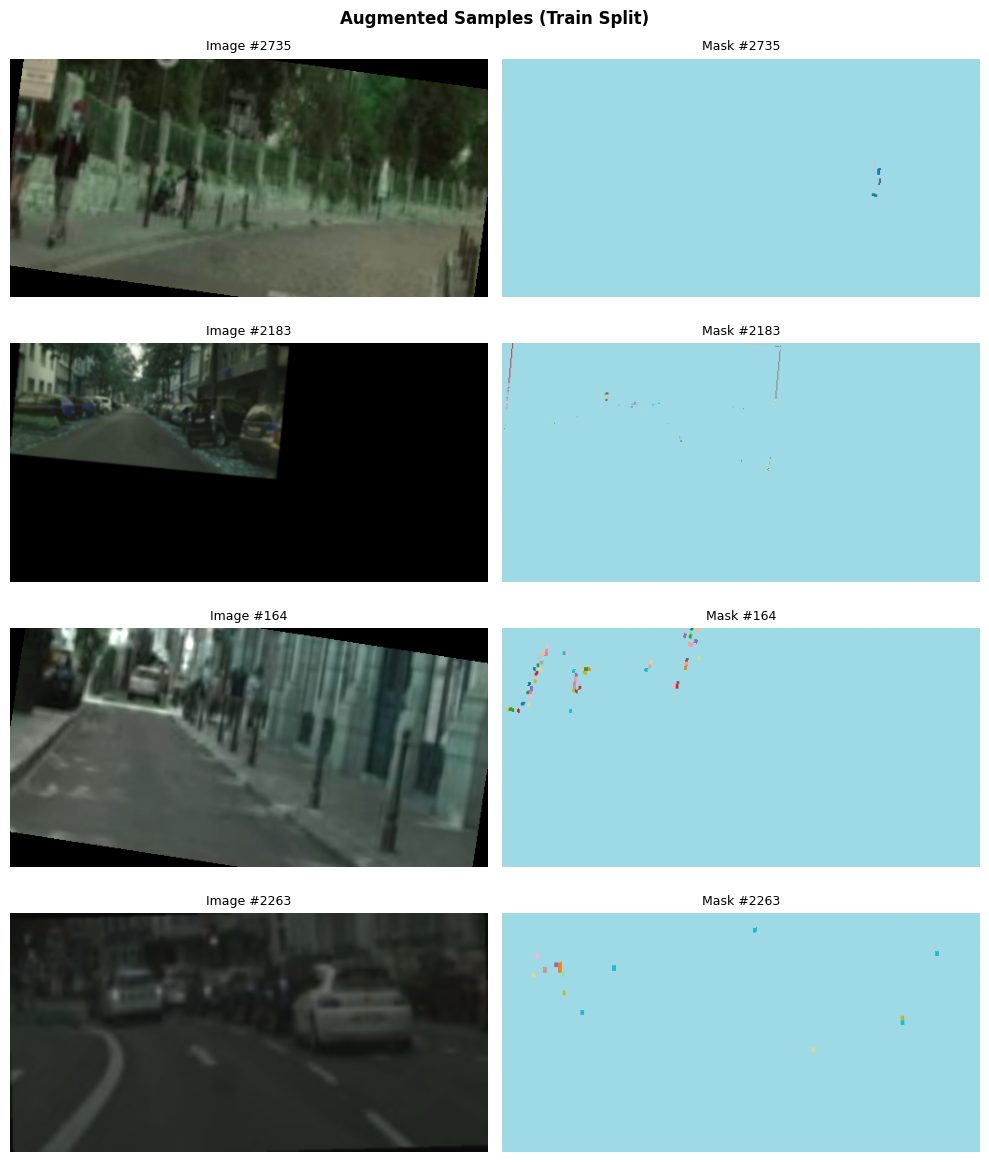

In [6]:
class CityscapesDataset(Dataset):
    def __init__(self, data_root: str, split: str = 'train', img_size: tuple = (256, 512)):
        self.augment = SegmentationAugmentation(img_size, split)
        self.pairs   = []

        img_dir   = os.path.join(data_root, split, 'img')
        mask_dir  = os.path.join(data_root, split, 'label')
        
        img_files = sorted(glob.glob(os.path.join(img_dir, '*.png')))

        for img_path in img_files:
            fname = os.path.basename(img_path)
            mask_path = os.path.join(mask_dir, fname)
            if os.path.exists(mask_path):
                self.pairs.append((img_path, mask_path))

        print(f'[{split}] {len(self.pairs)} image/mask pairs loaded.')

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        
        # Load Image
        image = Image.open(img_path).convert('RGB')
        
        # Load Mask as Grayscale (Mode 'L') or handle RGB conversion
        # The 'L' mode ensures we don't get the [H, W, 3] shape
        mask_raw = Image.open(mask_path).convert('L') 
        
        # Convert to numpy and remap IDs to 0-18
        mask_np = np.array(mask_raw)
        mask_indices = remap_labels(mask_np)
            
        # Convert back to PIL Image (Mode 'L') so the augmentation works
        mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
        
        return self.augment(image, mask)
# ── Preview augmentations ────────────────────────────────────────────────────
# Use the base DATA_ROOT here
train_preview = CityscapesDataset(
    data_root=DATA_ROOT, 
    split='train', 
    img_size=IMG_SIZE
)

visualise_augmentations(train_preview, n=4)

In [7]:
def get_model(num_classes: int) -> nn.Module:
    model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
    model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    if model.aux_classifier:
        model.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    return model.to(device)


In [8]:
class SegmentationMetrics:
    """Confusion-matrix based metrics: Pixel Acc, mIoU, Dice, Precision, Recall."""

    def __init__(self, num_classes: int, ignore_index: int = 255):
        self.num_classes  = num_classes
        self.ignore_index = ignore_index
        self.reset()

    def reset(self):
        self.confusion = np.zeros((self.num_classes, self.num_classes), dtype=np.int64)

    def update(self, logits: torch.Tensor, target: torch.Tensor):
        pred   = logits.argmax(dim=1).cpu().numpy().flatten()
        target = target.cpu().numpy().flatten()
        valid  = target != self.ignore_index
        np.add.at(self.confusion, (target[valid], pred[valid]), 1)

    def compute(self) -> dict:
        tp = np.diag(self.confusion)
        fp = self.confusion.sum(axis=0) - tp
        fn = self.confusion.sum(axis=1) - tp
        total = self.confusion.sum()

        px_acc       = float(tp.sum() / total) if total > 0 else 0.0
        iou_denom    = (tp + fp + fn).astype(float)
        iou_per_cls  = np.where(iou_denom > 0, tp / iou_denom, np.nan)
        dice_denom   = (2*tp + fp + fn).astype(float)
        dice_per_cls = np.where(dice_denom > 0, 2*tp / dice_denom, np.nan)
        prec_per_cls = np.where((tp+fp) > 0, tp / (tp+fp).astype(float), np.nan)
        rec_per_cls  = np.where((tp+fn) > 0, tp / (tp+fn).astype(float), np.nan)

        return {
            'pixel_accuracy' : px_acc,
            'miou'           : float(np.nanmean(iou_per_cls)),
            'mdice'          : float(np.nanmean(dice_per_cls)),
            'mprecision'     : float(np.nanmean(prec_per_cls)),
            'mrecall'        : float(np.nanmean(rec_per_cls)),
            'iou_per_class'  : iou_per_cls,
            'dice_per_class' : dice_per_cls,
        }


In [9]:
def plot_epoch_metrics(history: dict):
    epochs = list(range(1, len(history['train_loss']) + 1))
    fig, axes = plt.subplots(1, 5, figsize=(28, 4))
    fig.suptitle(f'Training Progress — Epoch {epochs[-1]}',
                 fontsize=13, fontweight='bold')
    cfg = [
        ('Train Loss',        [('train_loss',     '#E74C3C', '-')],               'Loss'),
        ('Pixel Accuracy',    [('pixel_accuracy', '#2ECC71', '-')],               'Accuracy'),
        ('Mean IoU',          [('miou',           '#3498DB', '-')],               'IoU'),
        ('Mean Dice (F1)',    [('mdice',           '#9B59B6', '-')],              'Dice'),
        ('Precision/Recall',  [('mprecision',     '#F39C12', '-'),
                               ('mrecall',        '#1ABC9C', '--')],              'Score'),
    ]
    for ax, (title, series, ylabel) in zip(axes, cfg):
        for key, color, ls in series:
            if history.get(key):
                ax.plot(epochs, history[key], color=color, linestyle=ls,
                        linewidth=2, marker='o', markersize=4,
                        label=key.replace('_',' ').title())
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('Epoch', fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'metrics_epoch_{epochs[-1]:03d}.png', dpi=90, bbox_inches='tight')
    plt.show()


def plot_per_class_metrics(res: dict, epoch: int):
    x = np.arange(NUM_CLASSES)
    fig, axes = plt.subplots(1, 2, figsize=(22, 5))
    for ax, vals, color, metric in zip(
        axes,
        [np.nan_to_num(res['iou_per_class']), np.nan_to_num(res['dice_per_class'])],
        ['#3498DB', '#9B59B6'],
        ['IoU (Jaccard)', 'Dice (F1)']
    ):
        bars = ax.bar(x, vals, color=color, alpha=0.75,
                      edgecolor='white', linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel(metric)
        ax.set_title(f'Per-Class {metric} — Epoch {epoch}', fontweight='bold')
        ax.set_ylim(0, 1)
        ax.grid(axis='y', alpha=0.3)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=6)
    plt.tight_layout()
    plt.savefig(f'per_class_epoch_{epoch:03d}.png', dpi=90, bbox_inches='tight')
    plt.show()


In [10]:
def run_training_loop(
    data_root:  str,
    epochs:     int   = 50,
    batch_size: int   = 8,
    patience:   int   = 7,
    img_size:   tuple = (256, 512),
) -> nn.Module:
    # --- Corrected Dataset Initialization ---
    # These two lines must have exactly the same indentation (4 spaces)
    train_ds = CityscapesDataset(data_root=data_root, split='train', img_size=img_size)
    val_ds   = CityscapesDataset(data_root=data_root, split='val',   img_size=img_size)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    model     = get_model(NUM_CLASSES)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)
    metrics   = SegmentationMetrics(NUM_CLASSES, IGNORE_INDEX)

    history = {k: [] for k in ['train_loss','pixel_accuracy','miou','mdice','mprecision','mrecall']}
    best_miou = 0.0
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        print(f'\n{"="*65}\n  EPOCH {epoch}/{epochs}   lr={scheduler.get_last_lr()[0]:.2e}\n{"="*65}')

        model.train()
        running_loss = 0.0
        for imgs, masks in tqdm(train_loader, desc='  [Train]', leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            masks = masks.to(device).squeeze(1).long()
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out['out'], masks)
            if 'aux' in out:
                loss += 0.4 * criterion(out['aux'], masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        scheduler.step()
        avg_loss = running_loss / len(train_loader)
        history['train_loss'].append(avg_loss)

        model.eval()
        metrics.reset()
        with torch.no_grad():
            for imgs, masks in tqdm(val_loader, desc='  [Val]  ', leave=False):
                logits = model(imgs.to(device))['out']
                metrics.update(logits, masks.to(device))

        res = metrics.compute()
        for k in ['pixel_accuracy','miou','mdice','mprecision','mrecall']:
            history[k].append(res[k])

        # Logging and Plotting
        plot_epoch_metrics(history)
        plot_per_class_metrics(res, epoch)

        if res['miou'] > best_miou:
            best_miou = res['miou']
            patience_counter = 0
            torch.save(model.state_dict(), 'best_deeplabv3_cityscapes.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    return model

[train] 2975 image/mask pairs loaded.


/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')


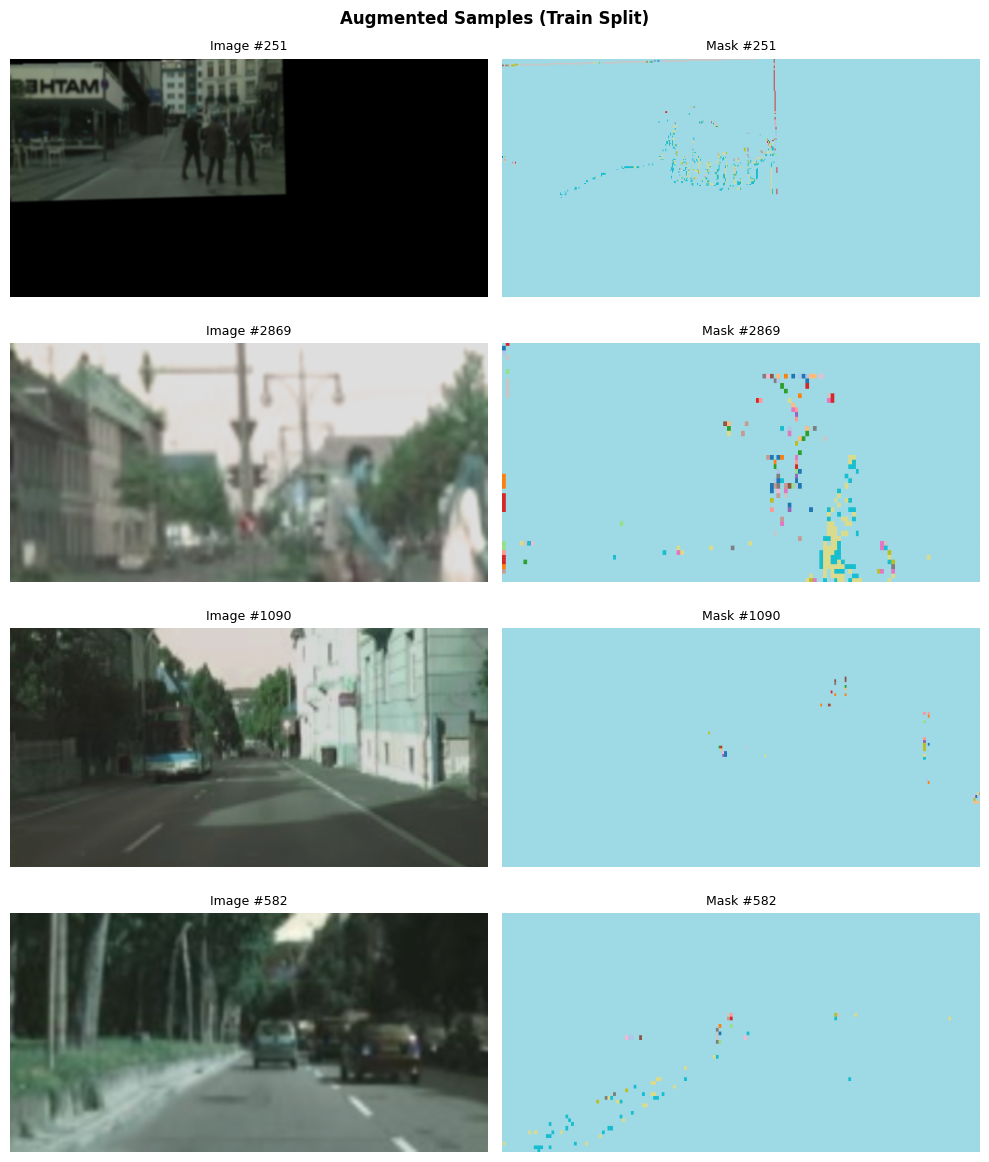

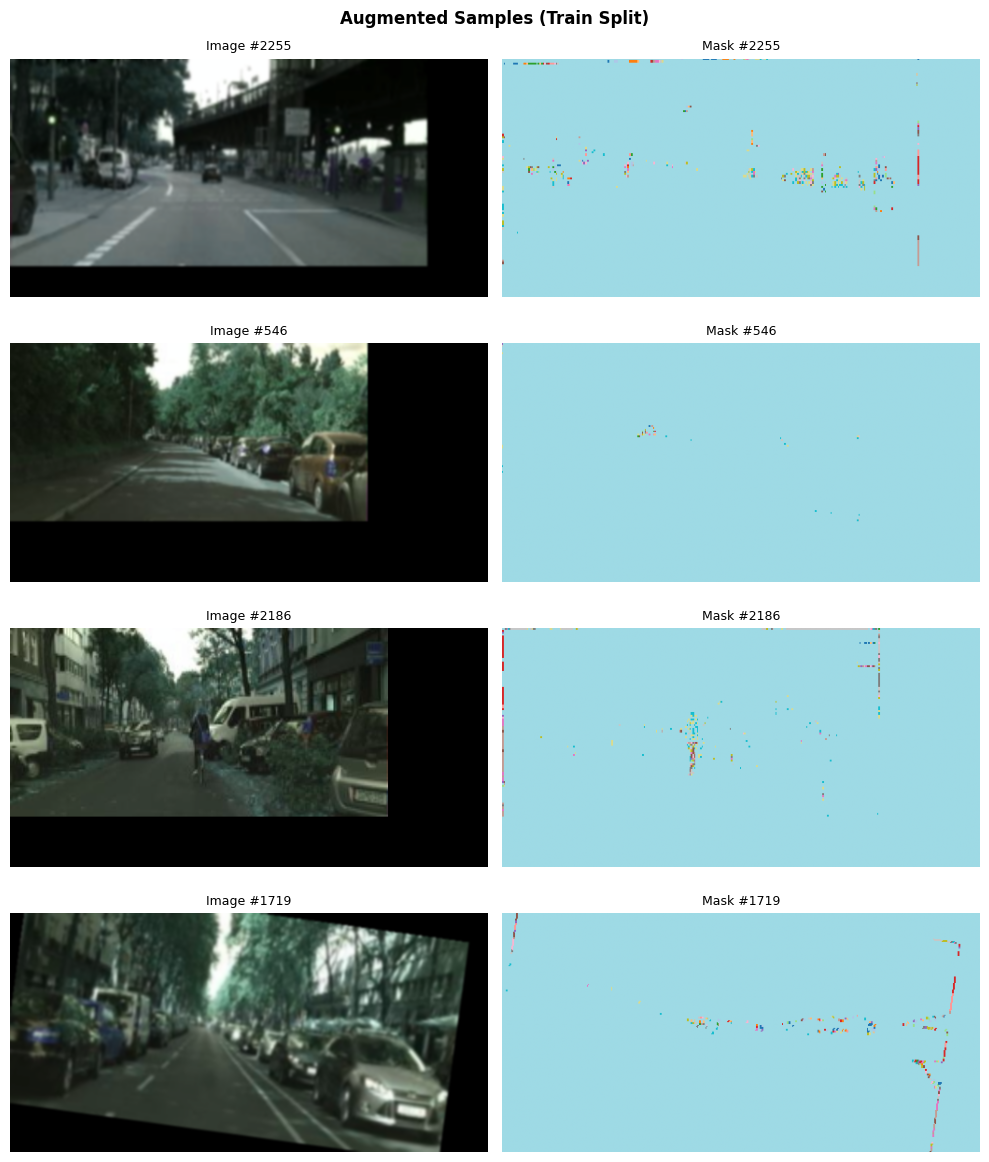

In [11]:
# ── Preview augmentations before training ────────────────────────────────────
train_preview = CityscapesDataset(
    data_root=DATA_ROOT, # This now matches the class argument 'data_root'
    split='train',
    img_size=IMG_SIZE
)
# Check the length before sampling to avoid the ValueError
n_to_show = min(len(train_preview), 4)
if n_to_show > 0:
    visualise_augmentations(train_preview, n=n_to_show)
else:
    print("Dataset is empty. Check your DATA_ROOT and folder structure.")
visualise_augmentations(train_preview, n=4)


[train] 2975 image/mask pairs loaded.
[val] 500 image/mask pairs loaded.
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 163MB/s]



  EPOCH 1/50   lr=1.00e-04


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

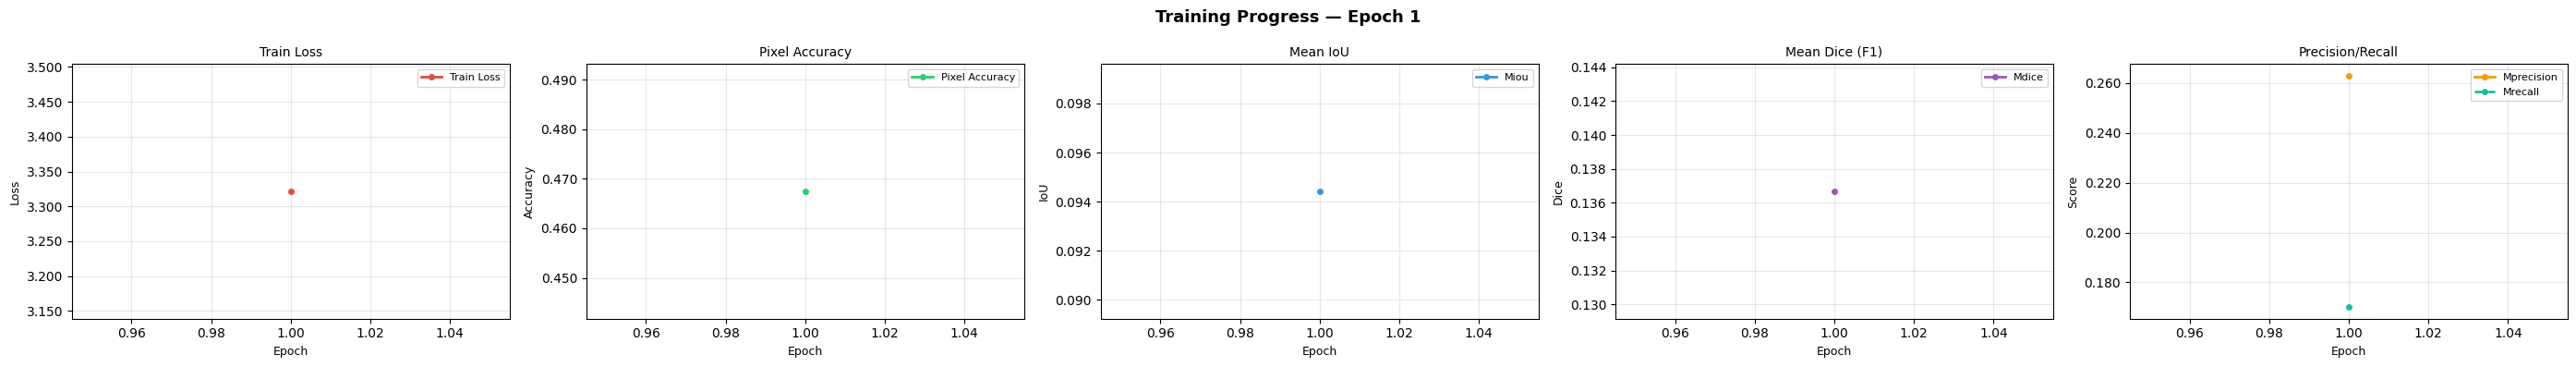

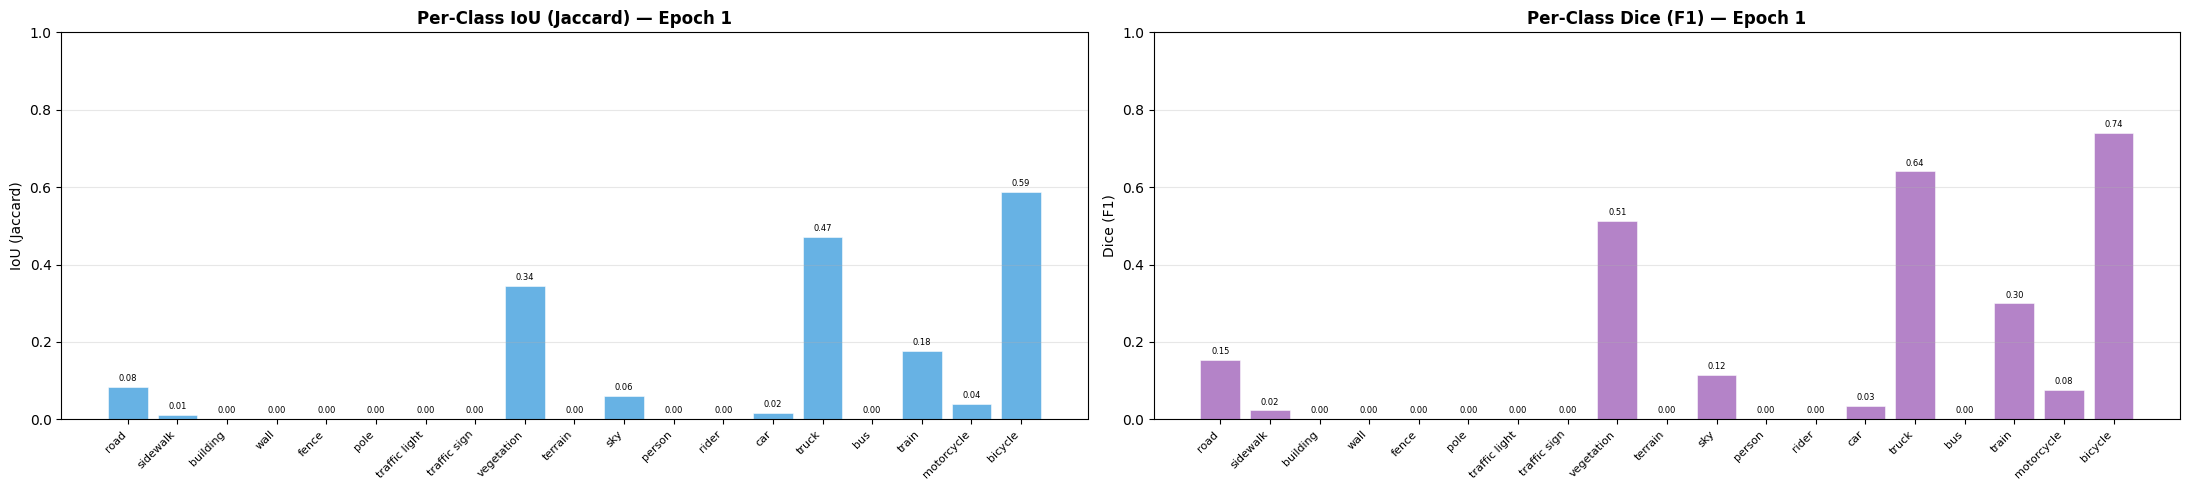


  EPOCH 2/50   lr=9.99e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

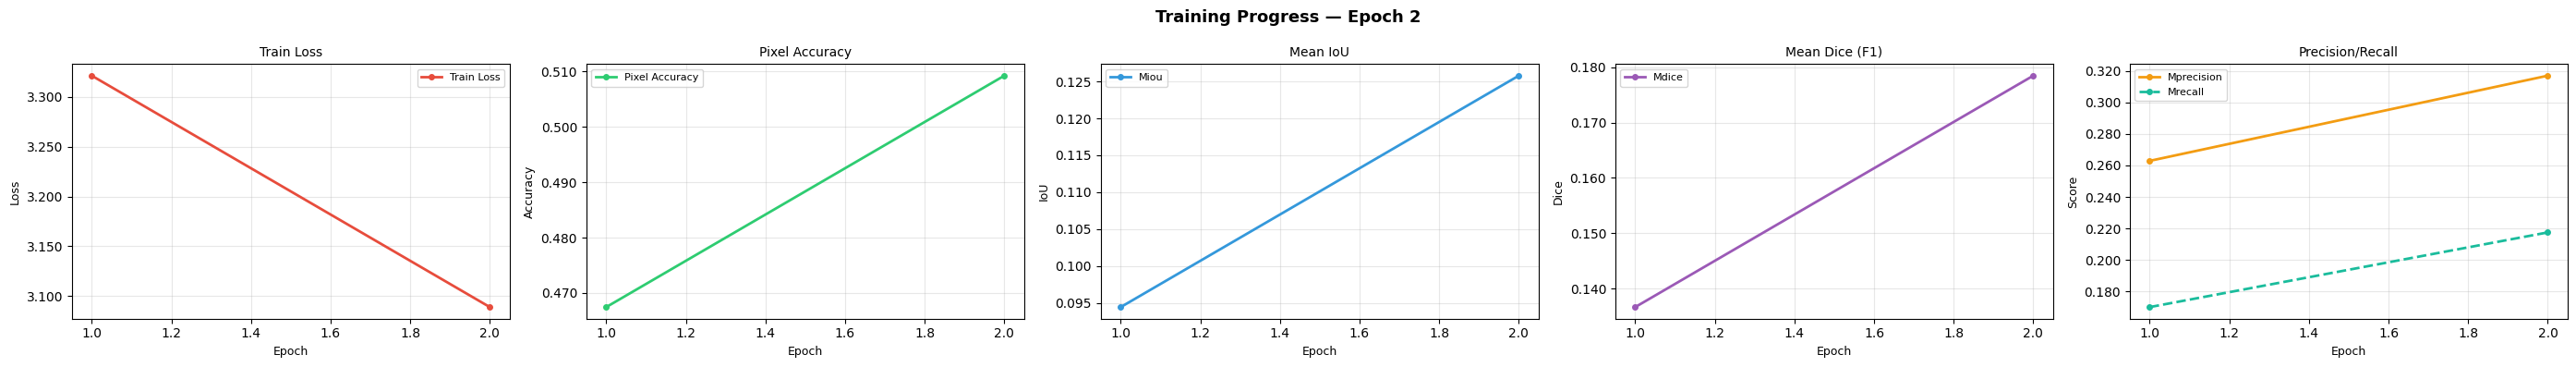

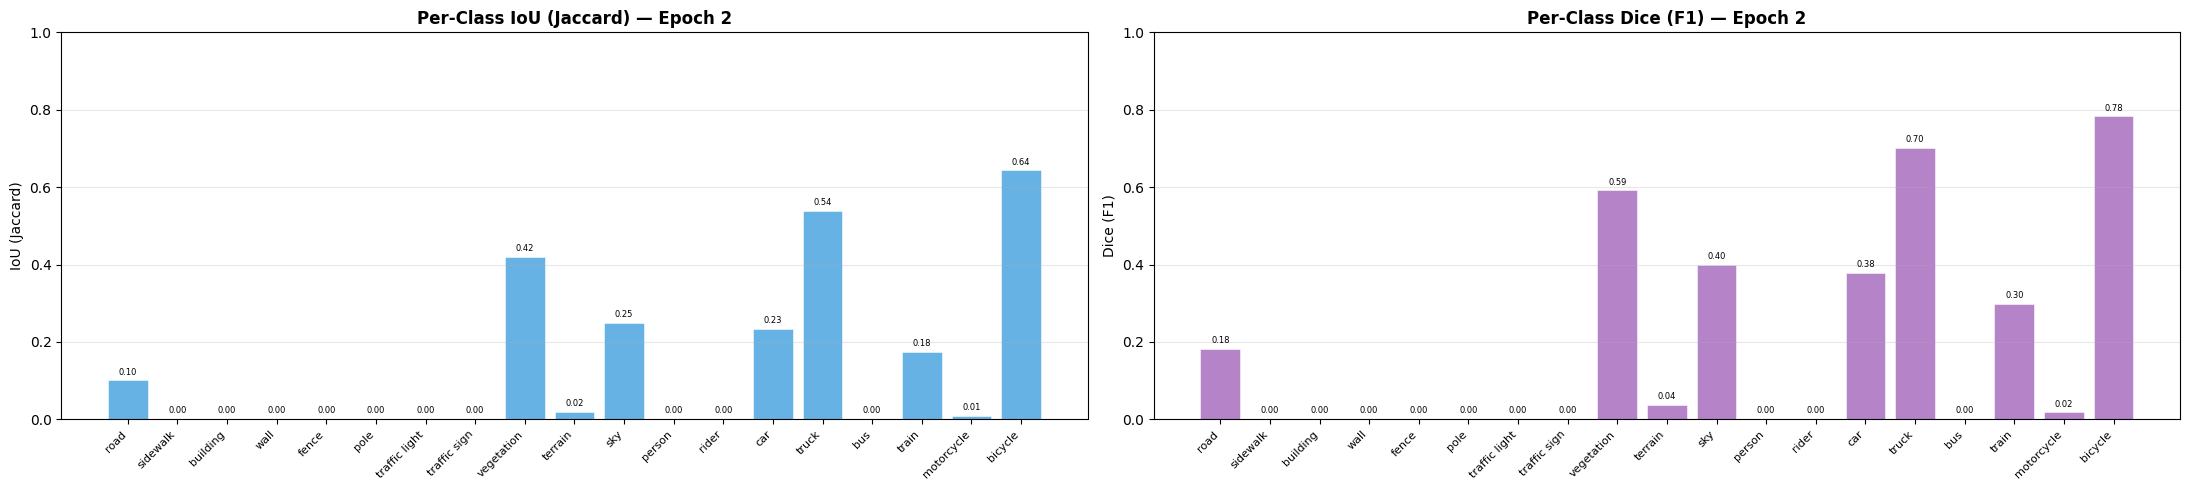


  EPOCH 3/50   lr=9.96e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

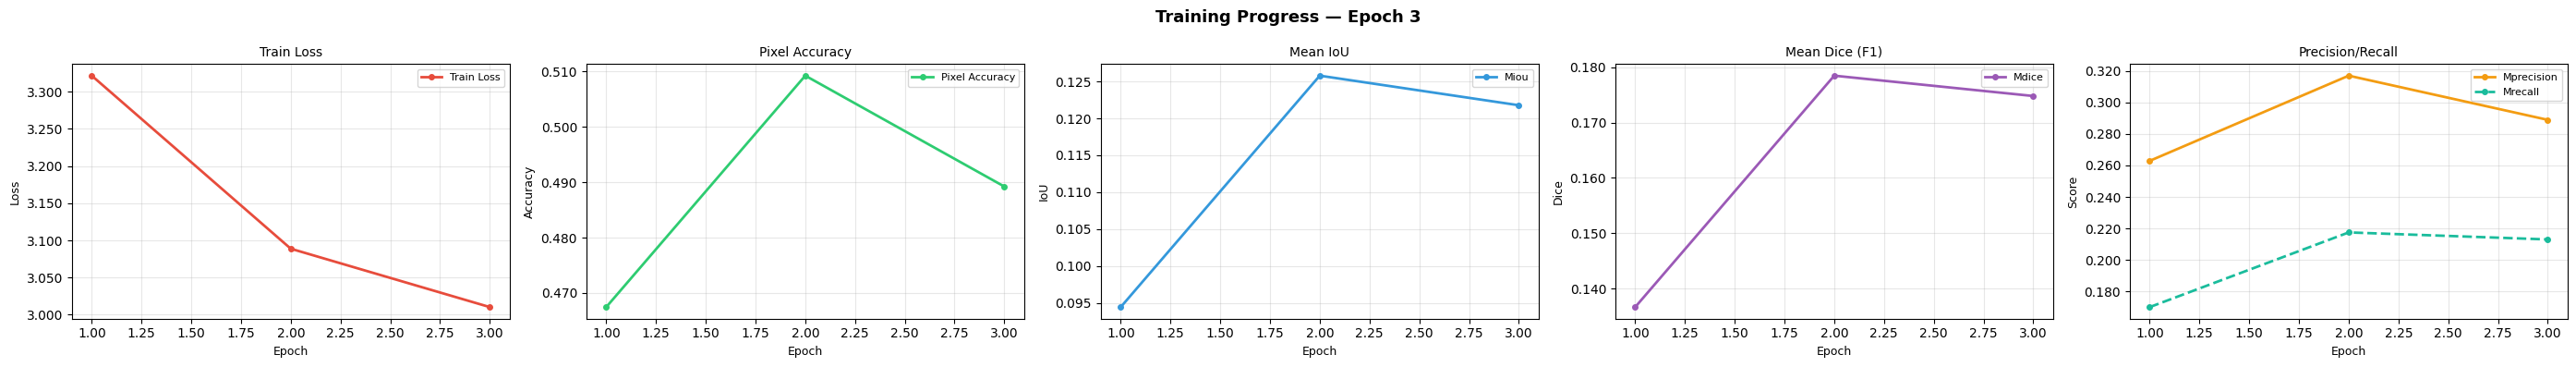

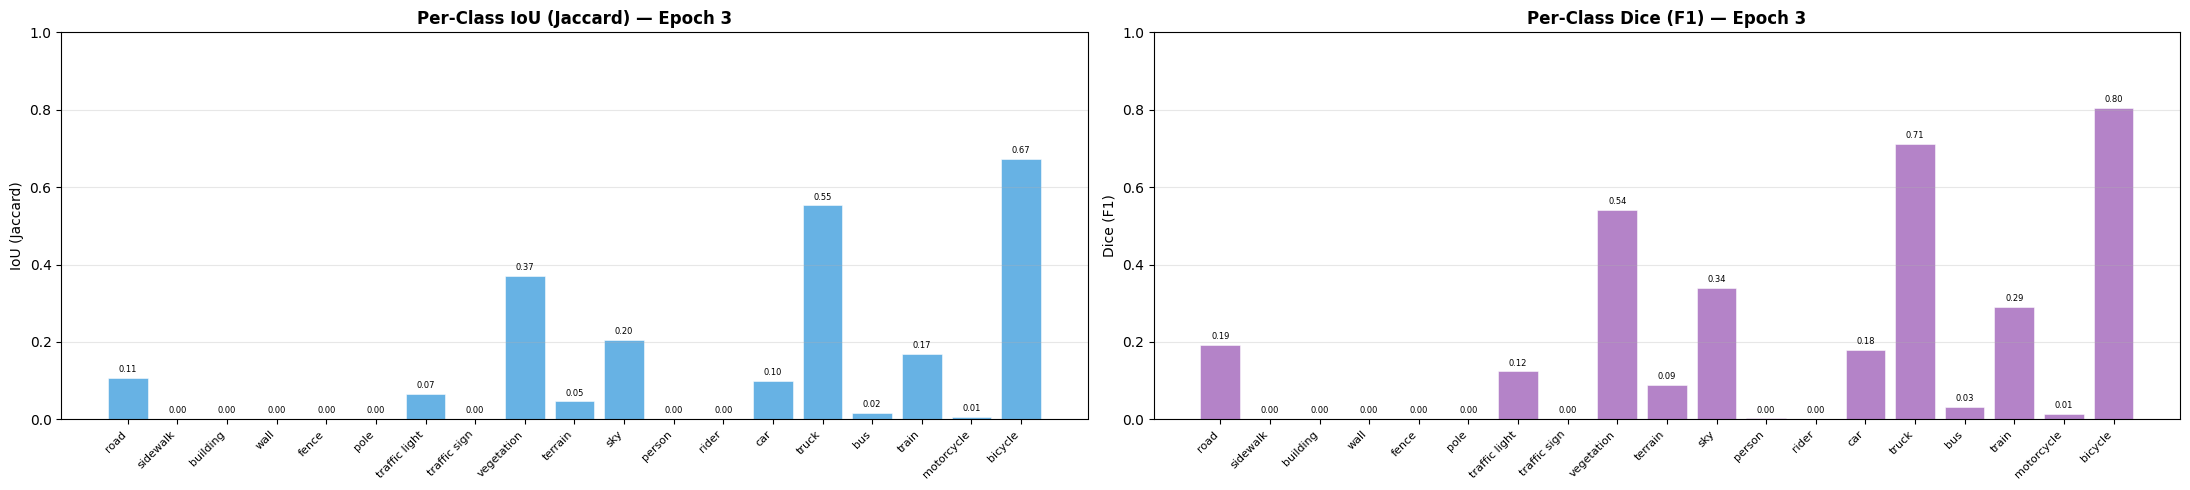


  EPOCH 4/50   lr=9.91e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

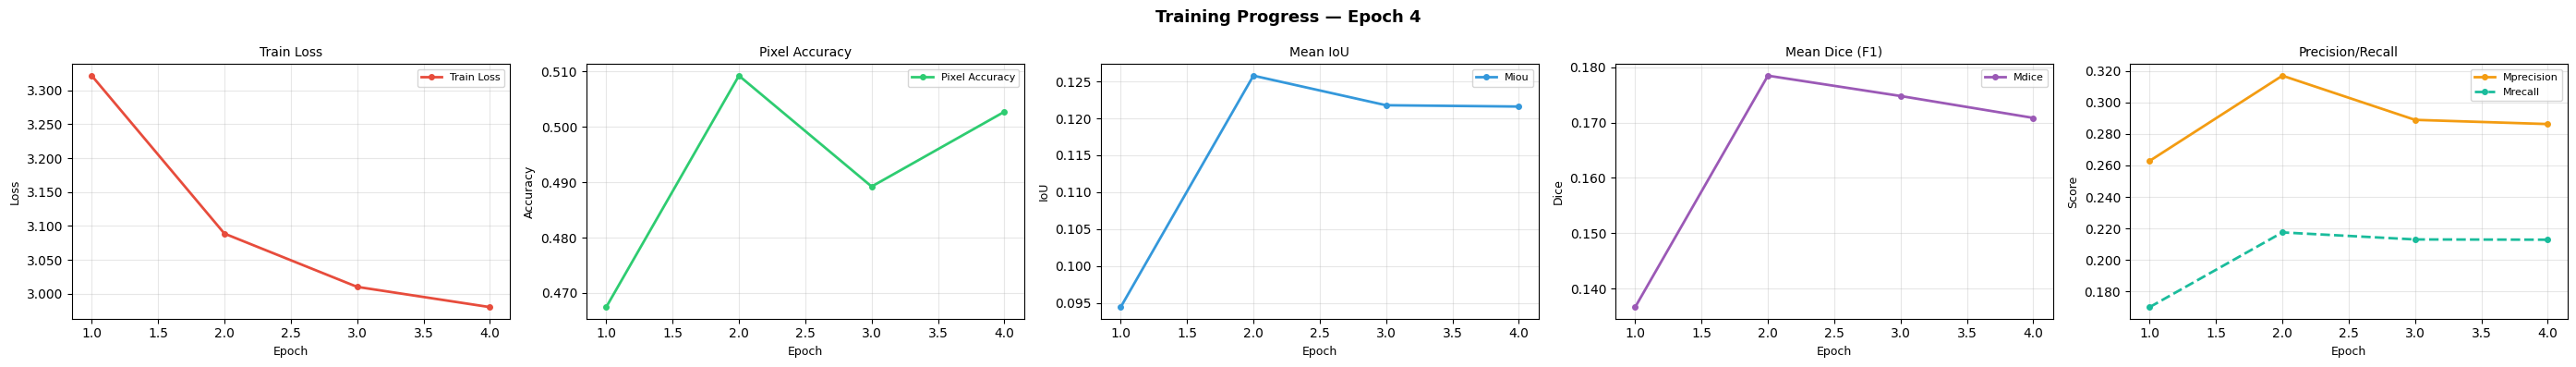

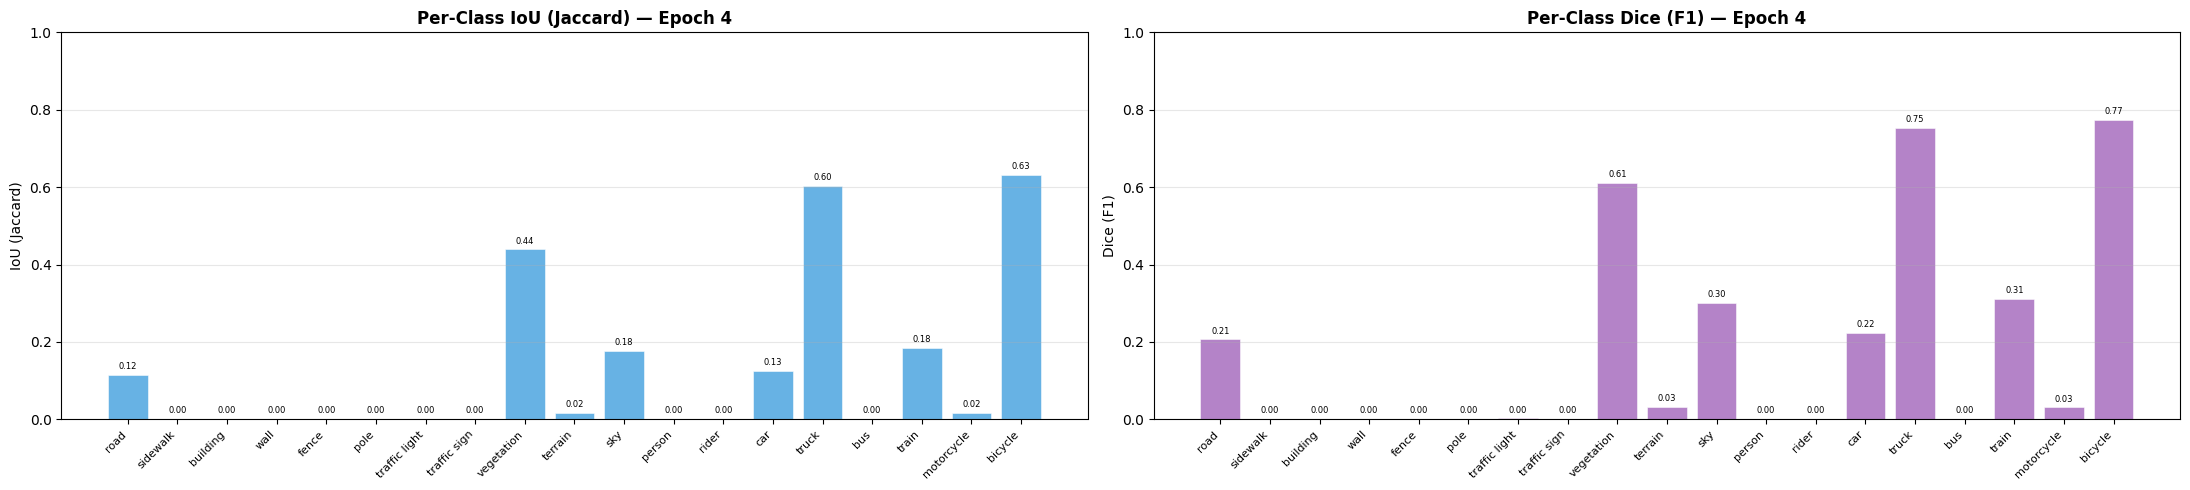


  EPOCH 5/50   lr=9.84e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

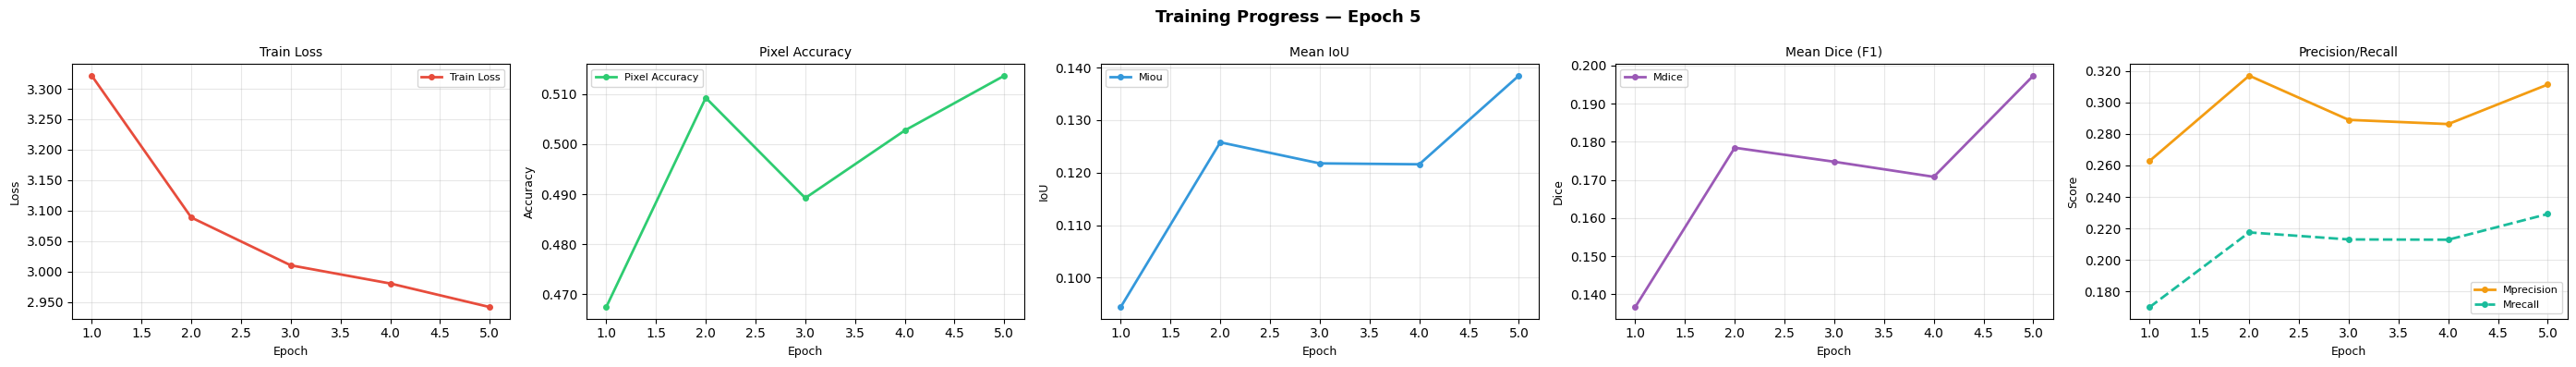

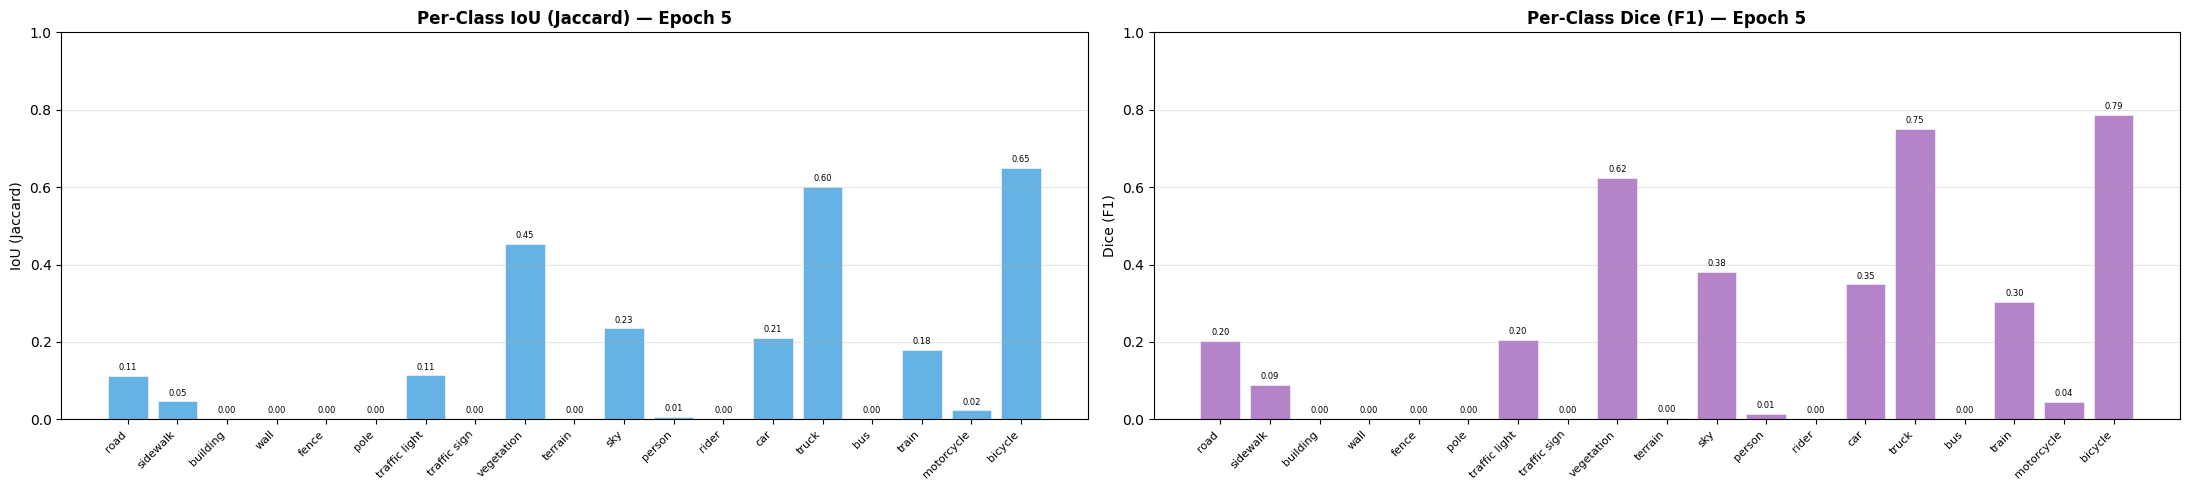


  EPOCH 6/50   lr=9.76e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

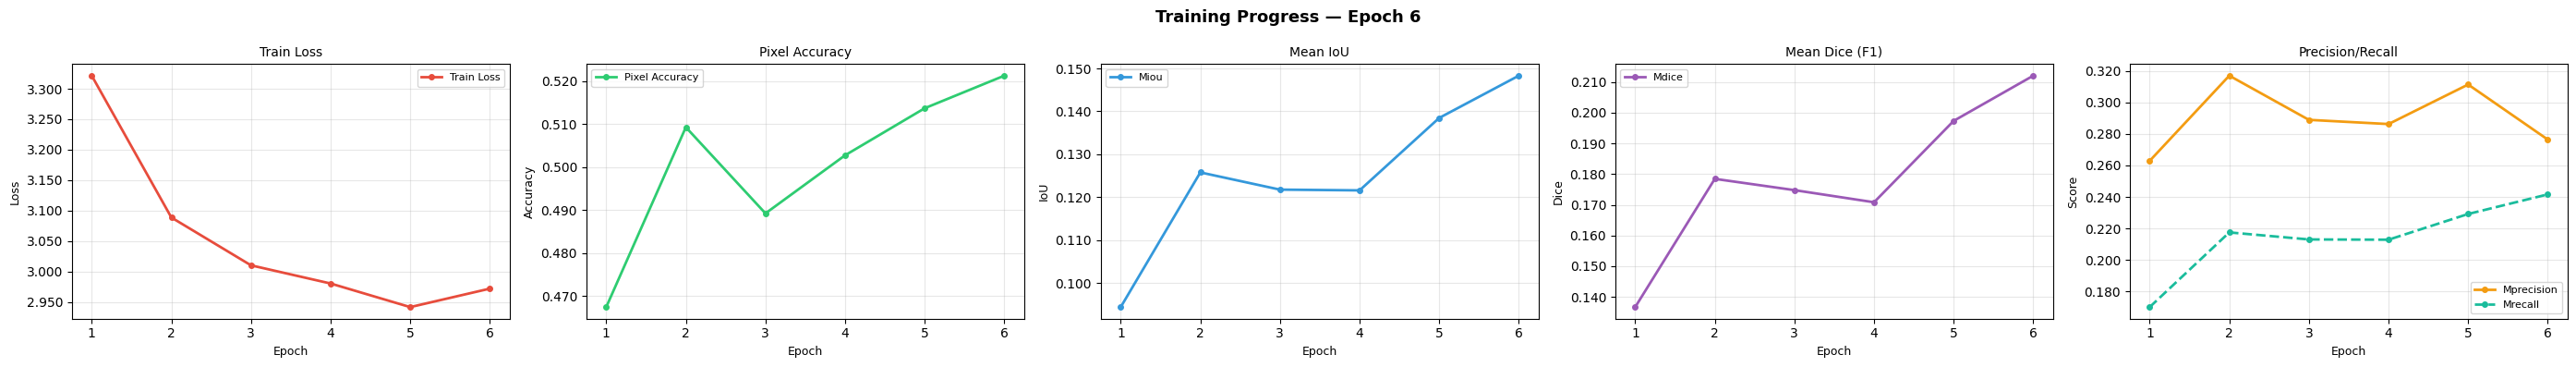

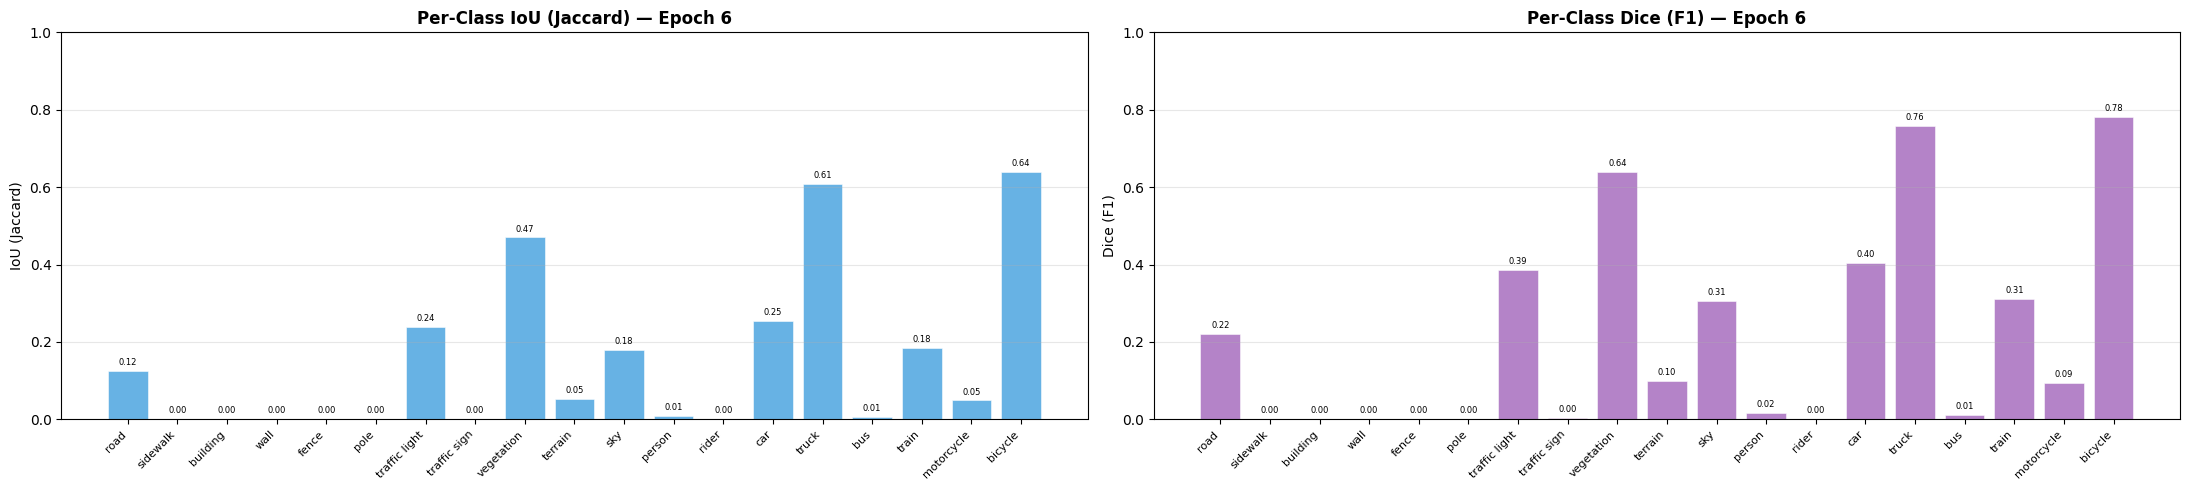


  EPOCH 7/50   lr=9.65e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

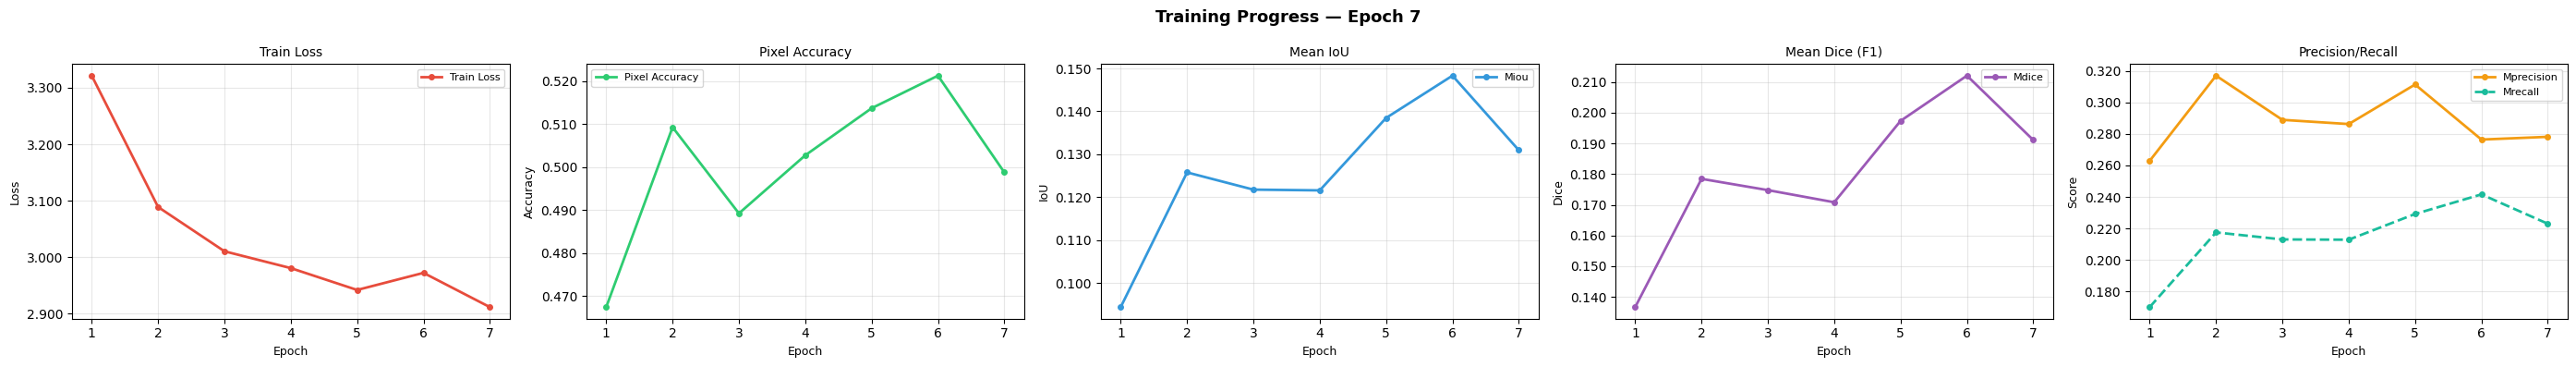

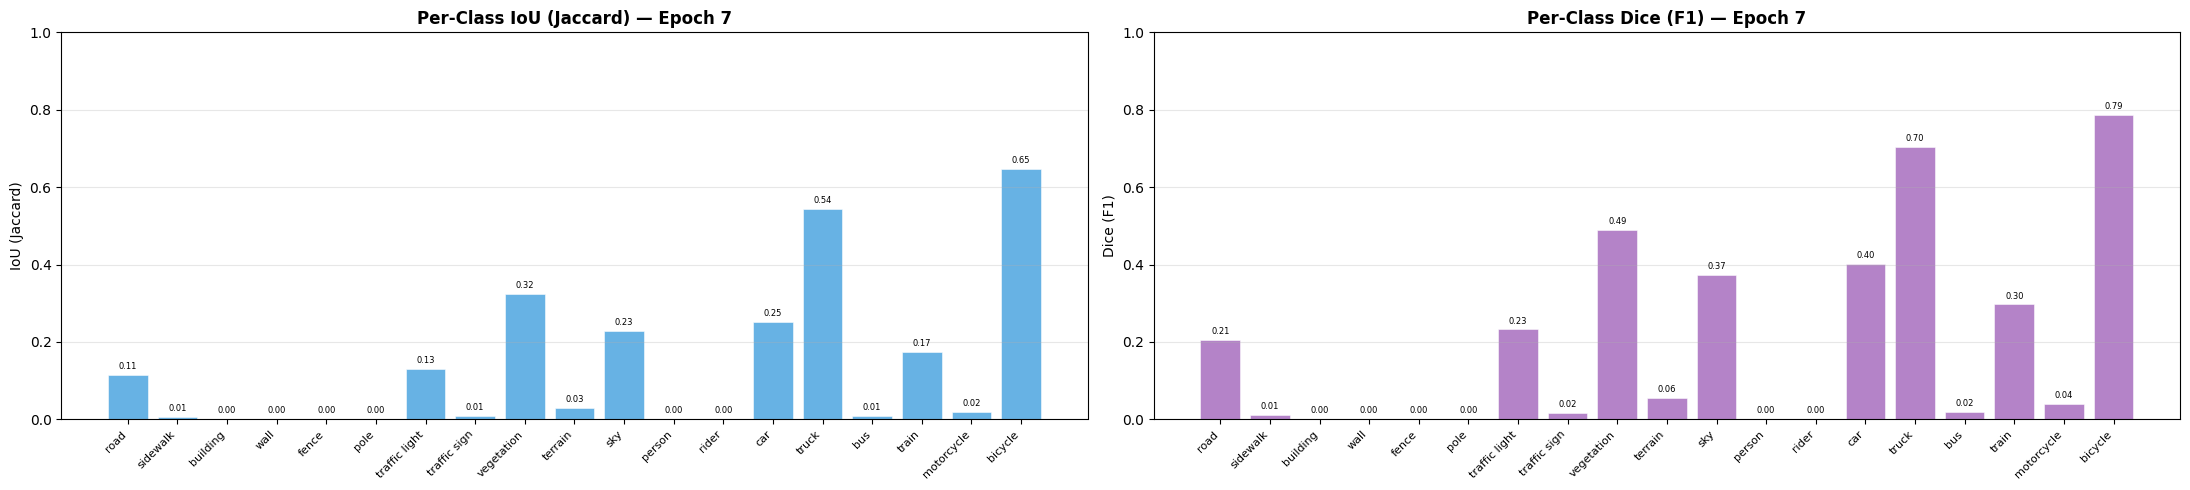


  EPOCH 8/50   lr=9.52e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

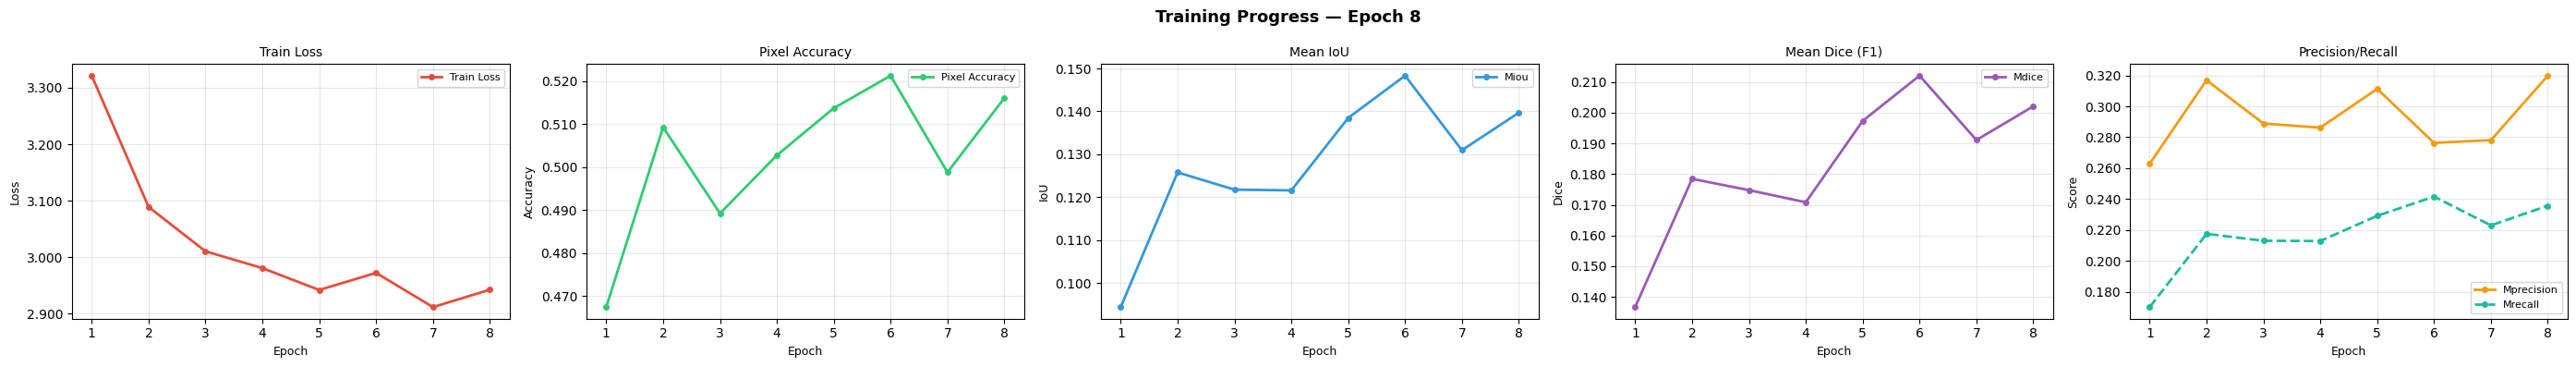

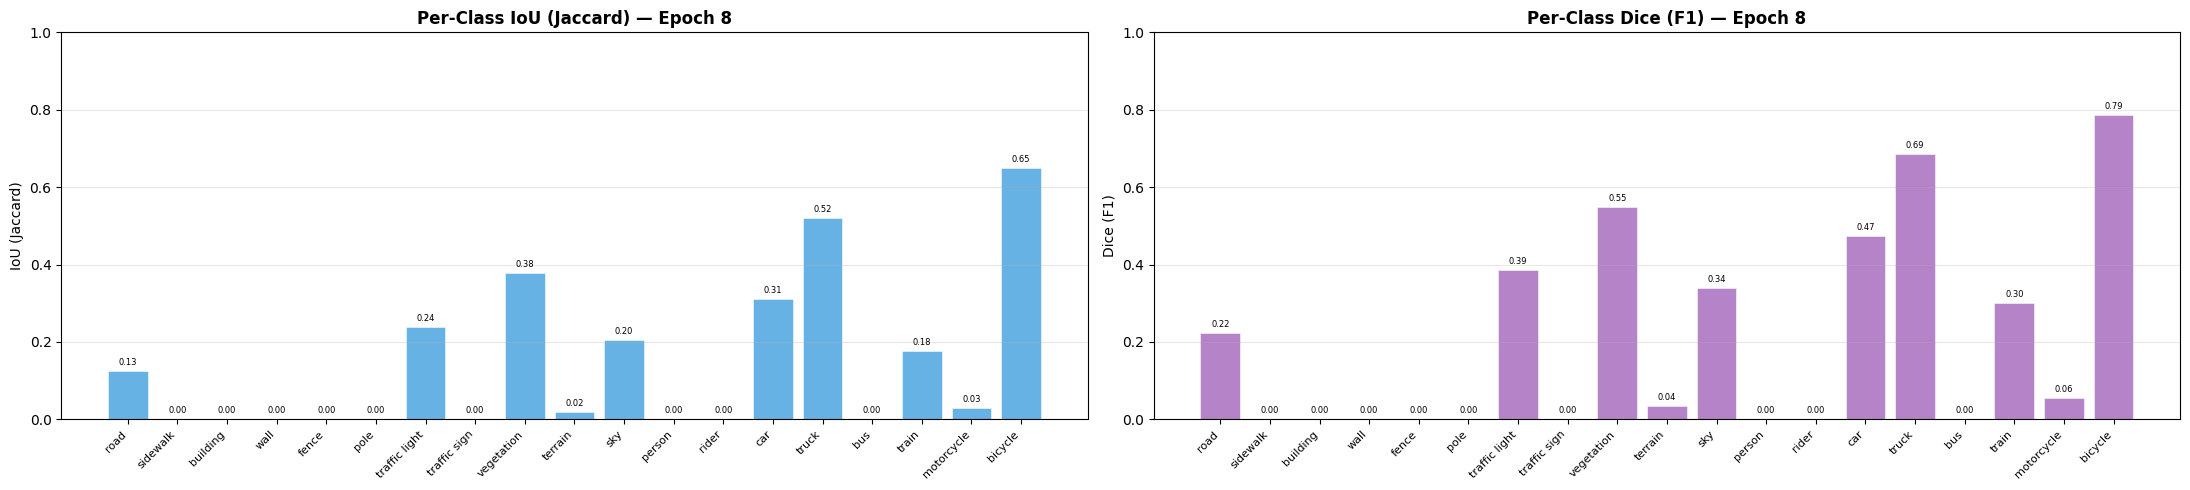


  EPOCH 9/50   lr=9.38e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

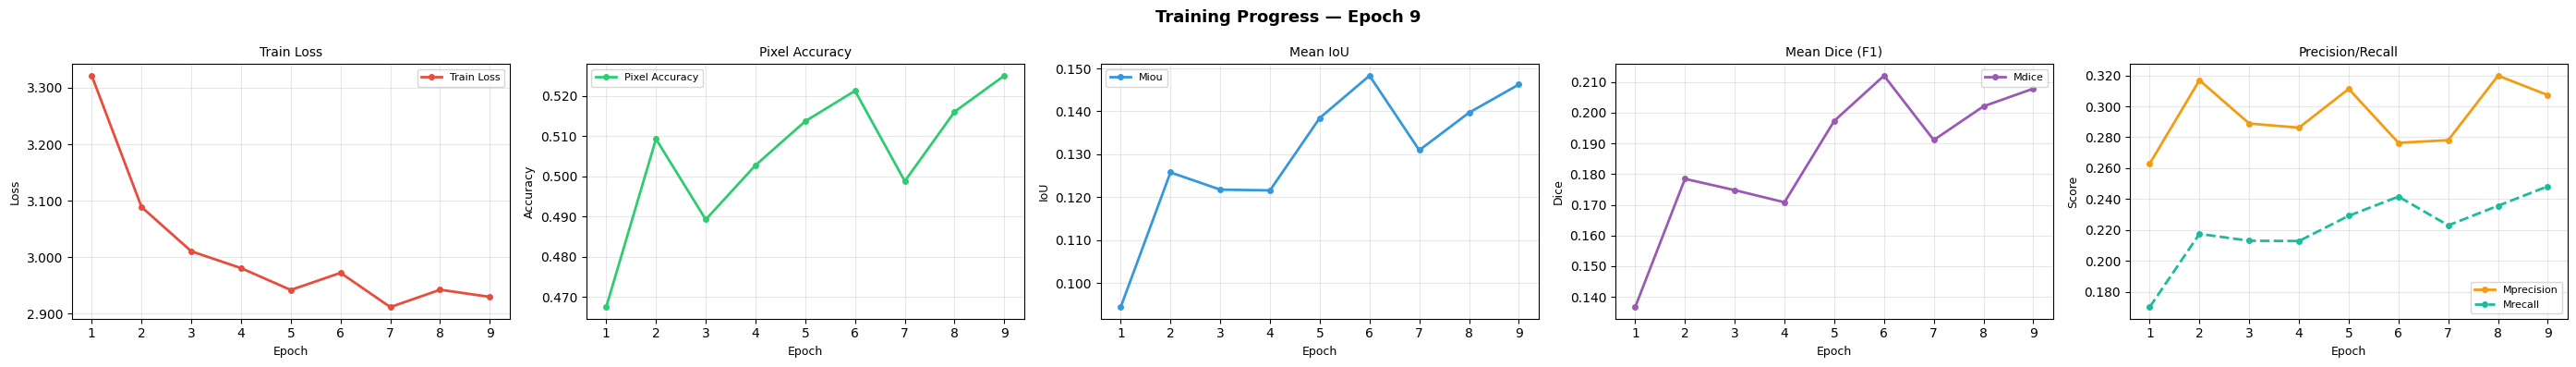

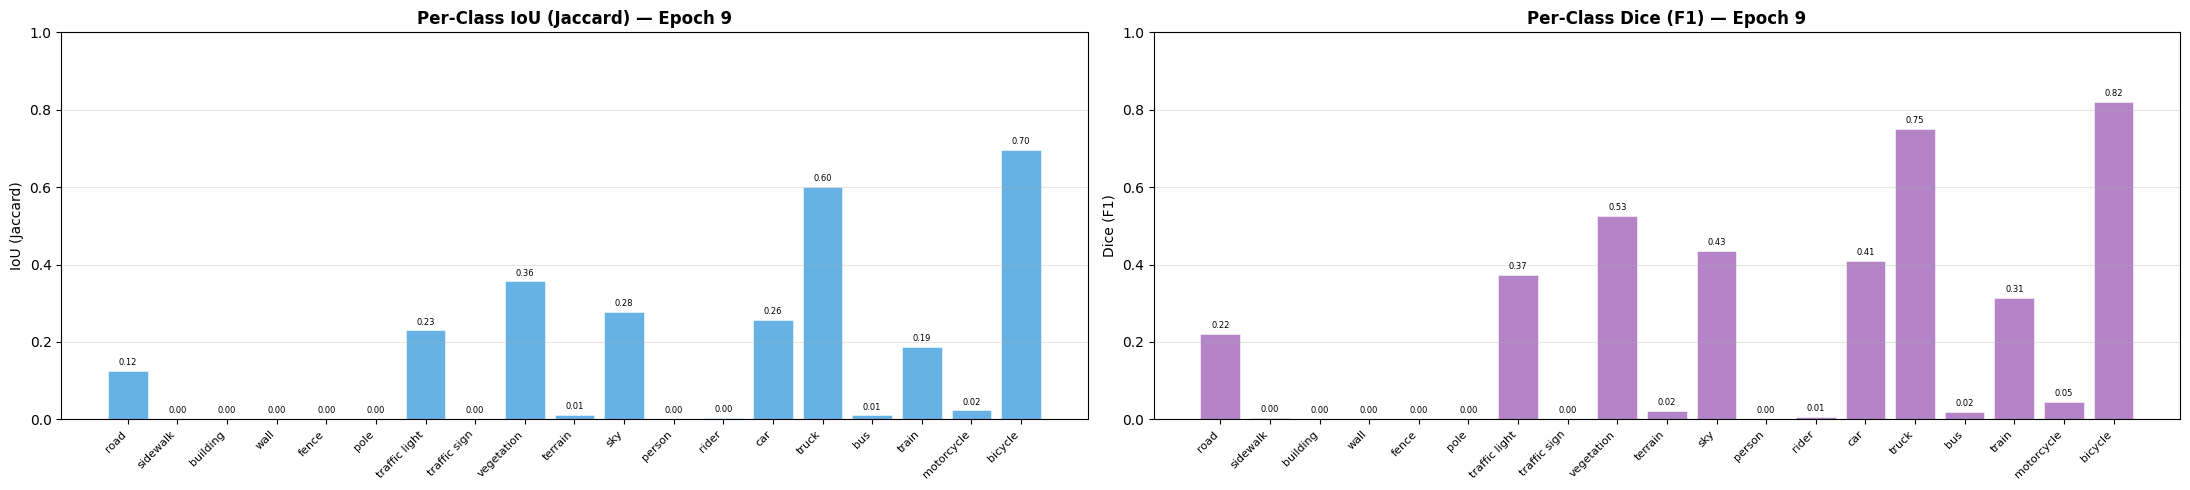


  EPOCH 10/50   lr=9.22e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

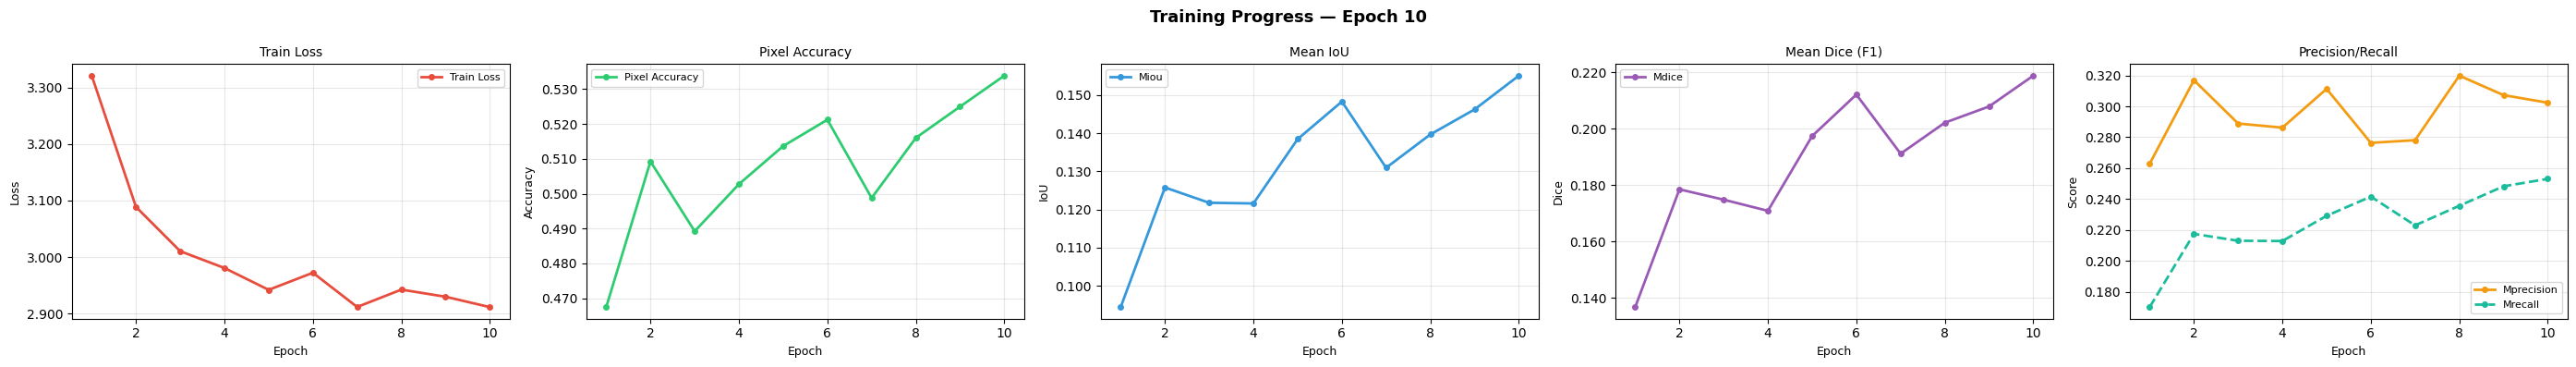

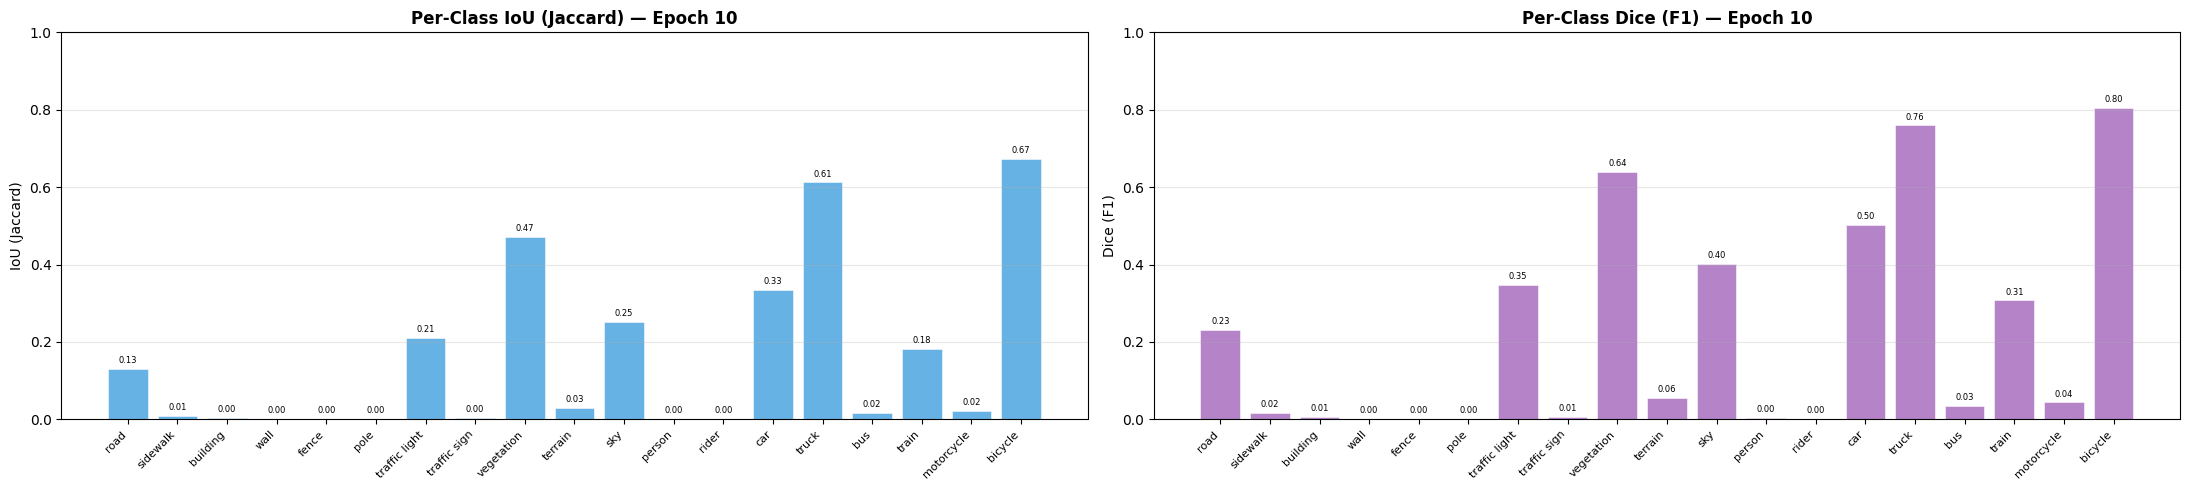


  EPOCH 11/50   lr=9.05e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

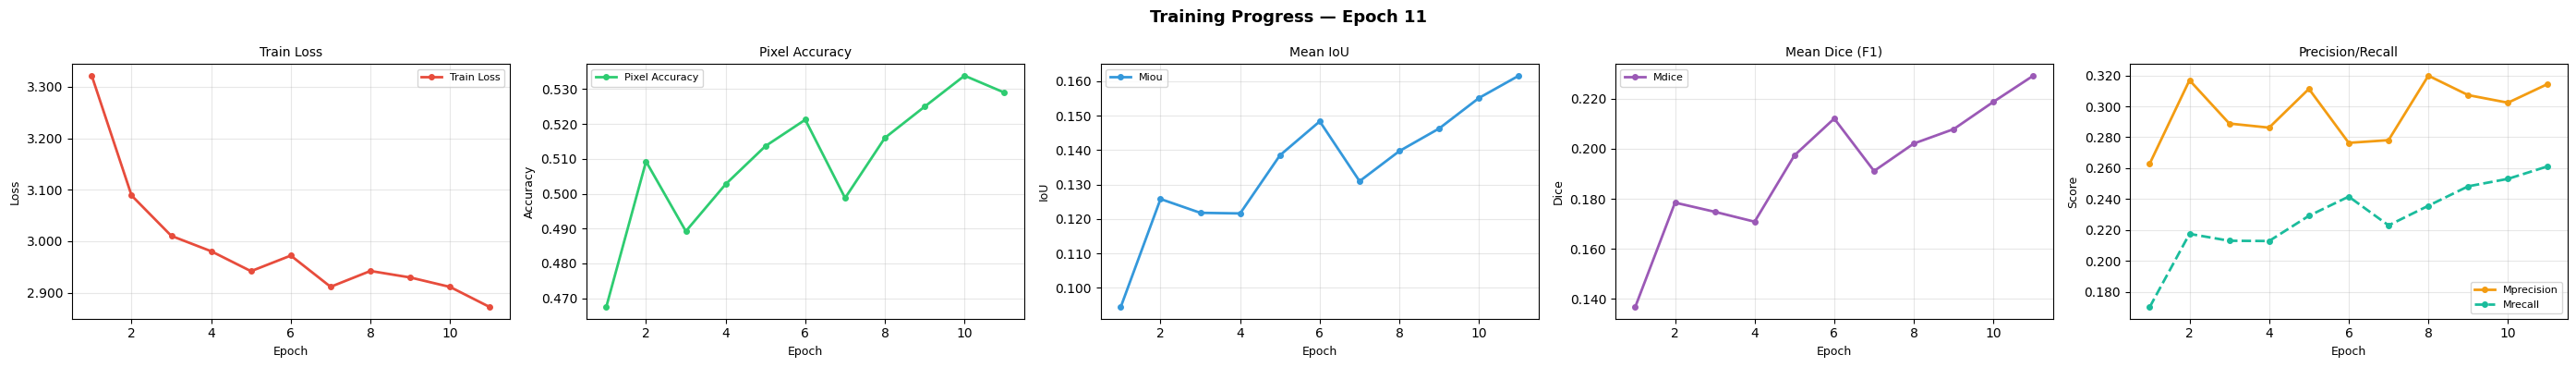

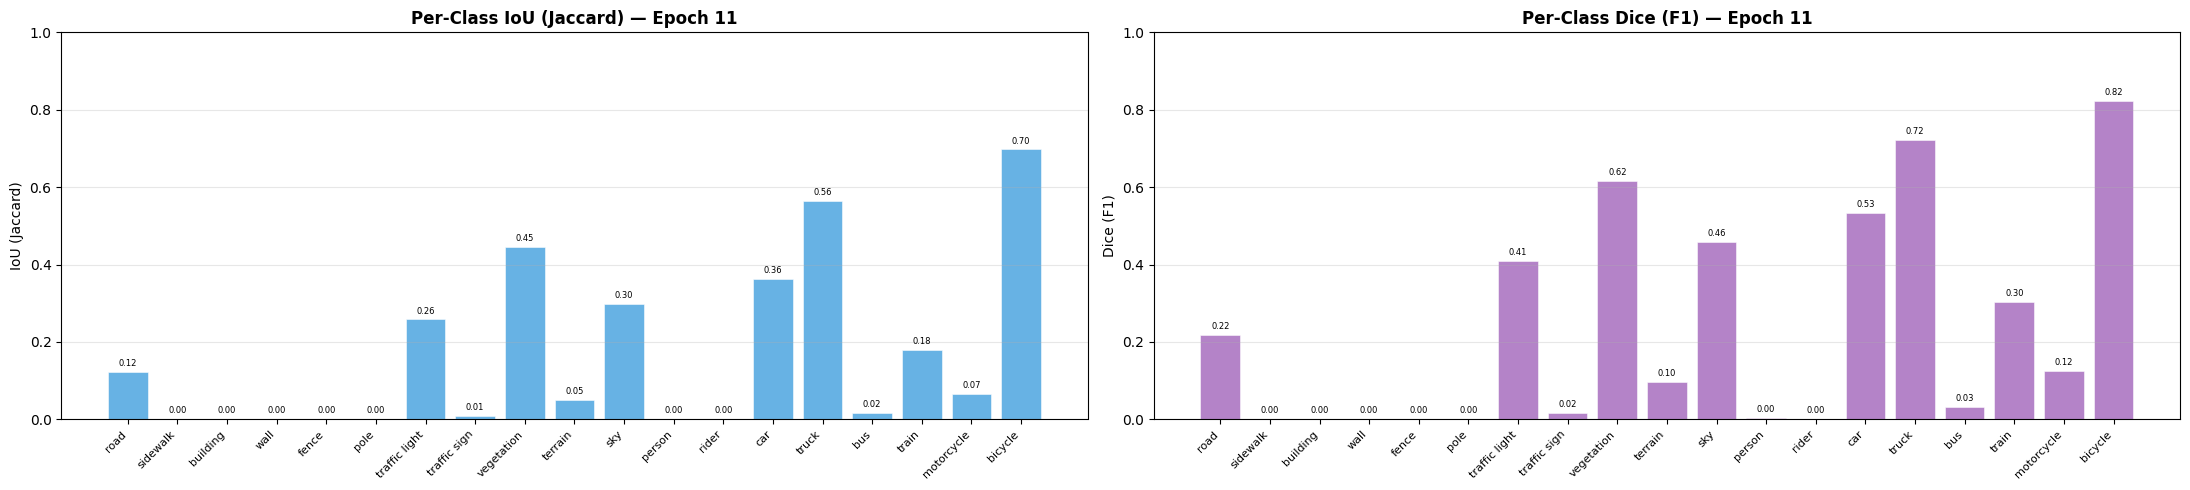


  EPOCH 12/50   lr=8.85e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

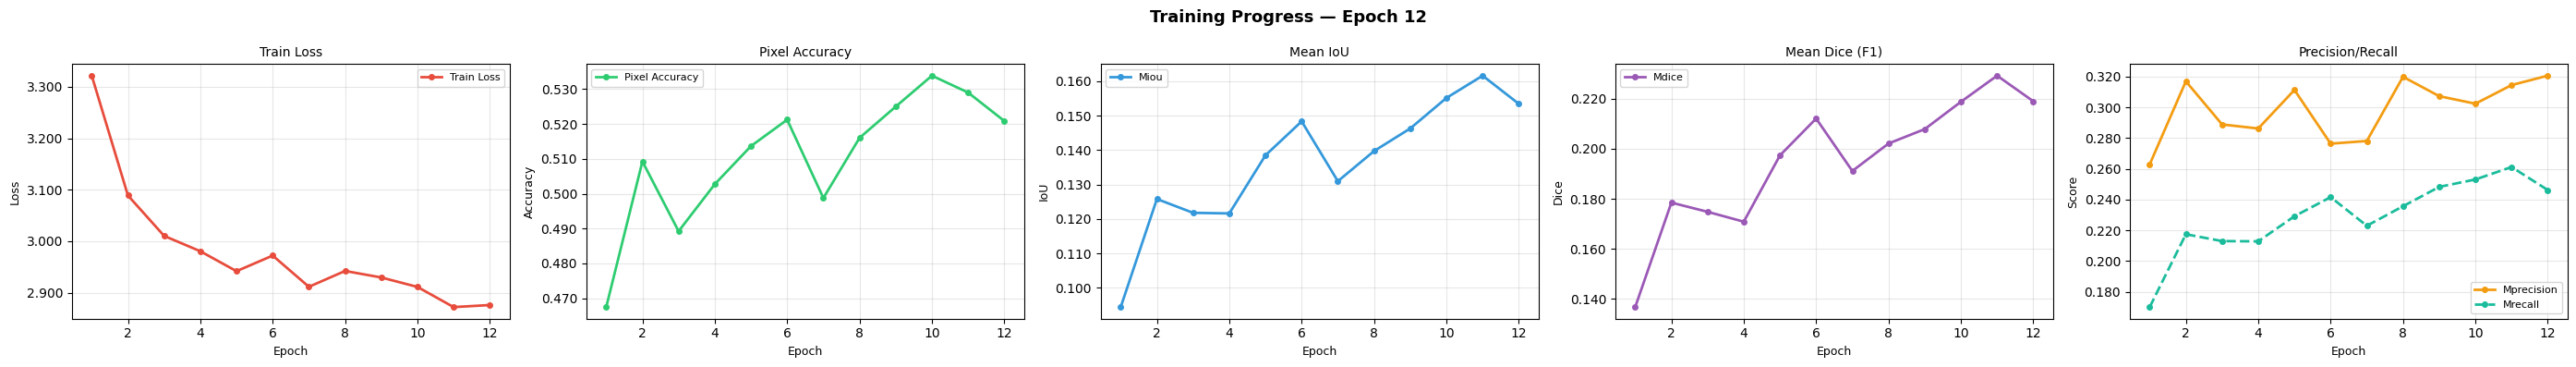

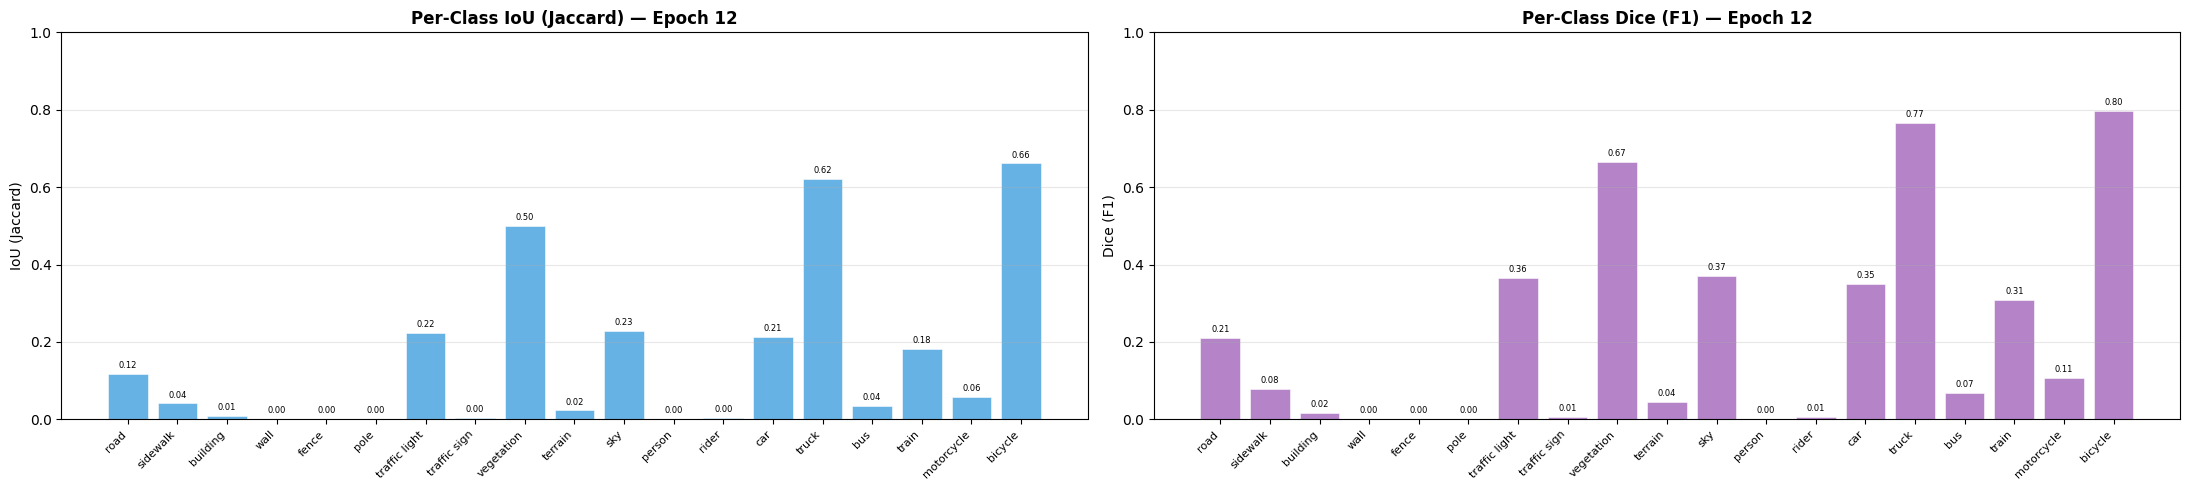


  EPOCH 13/50   lr=8.64e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

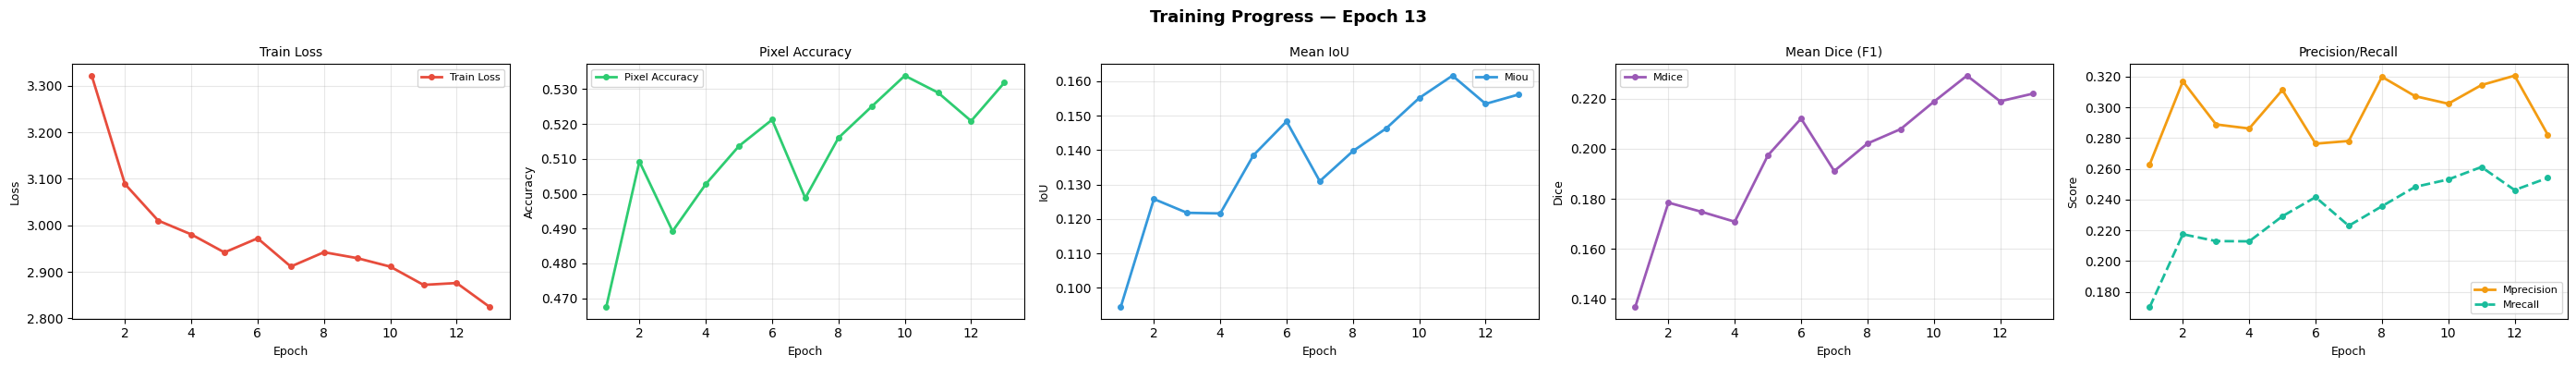

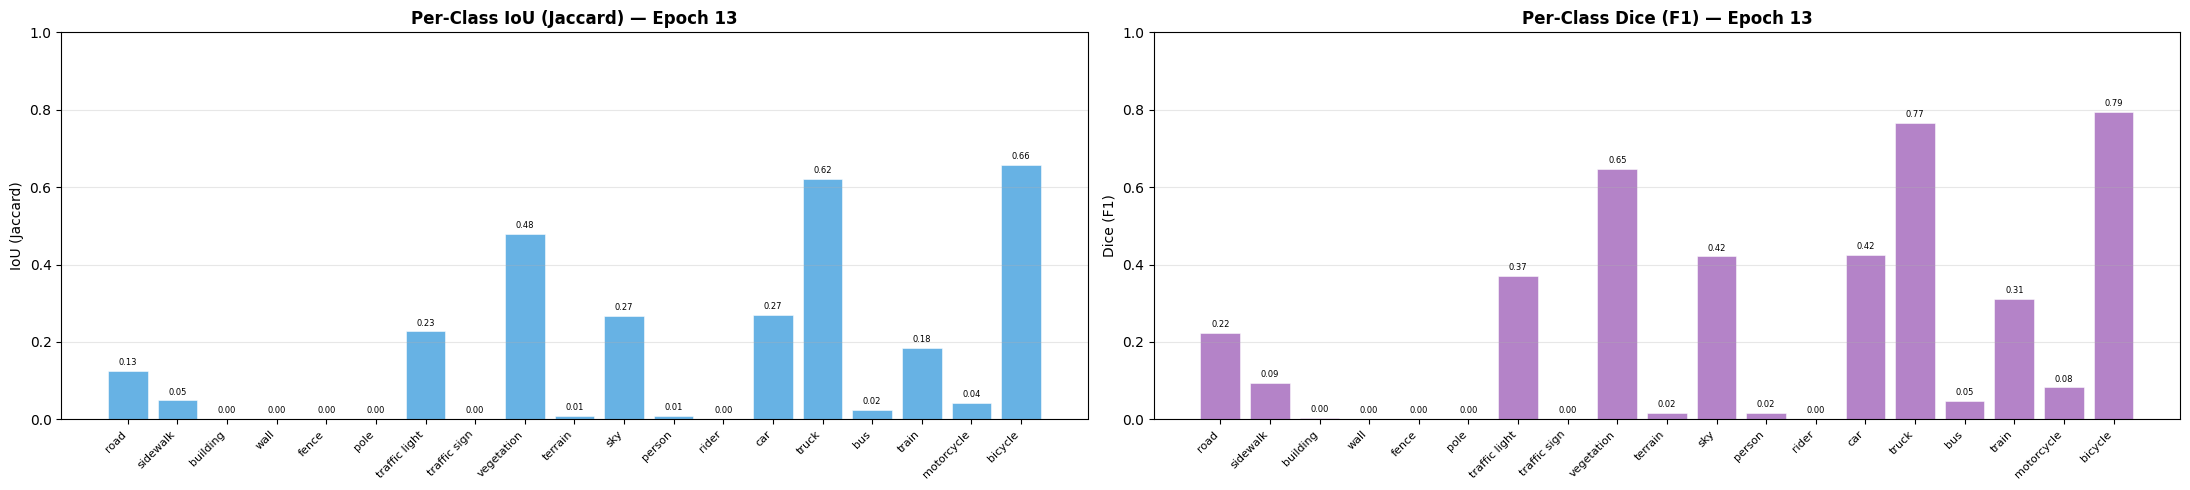


  EPOCH 14/50   lr=8.42e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

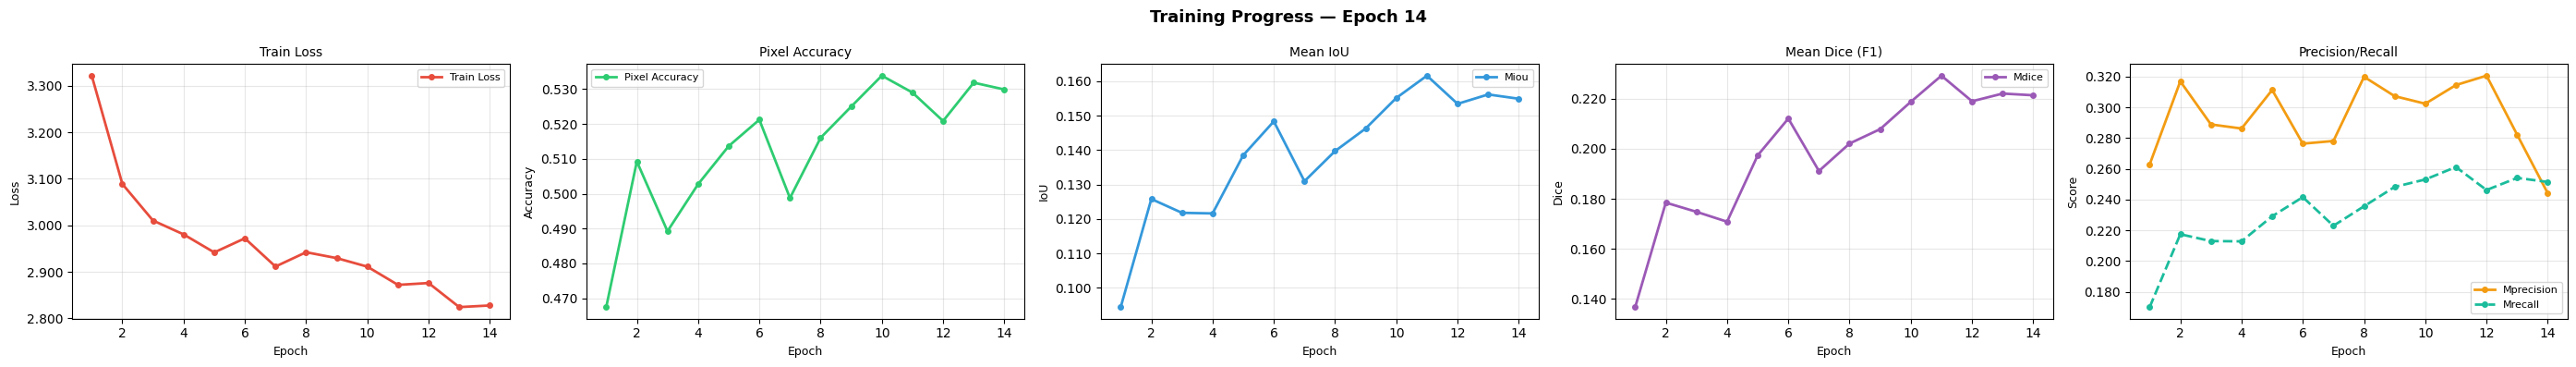

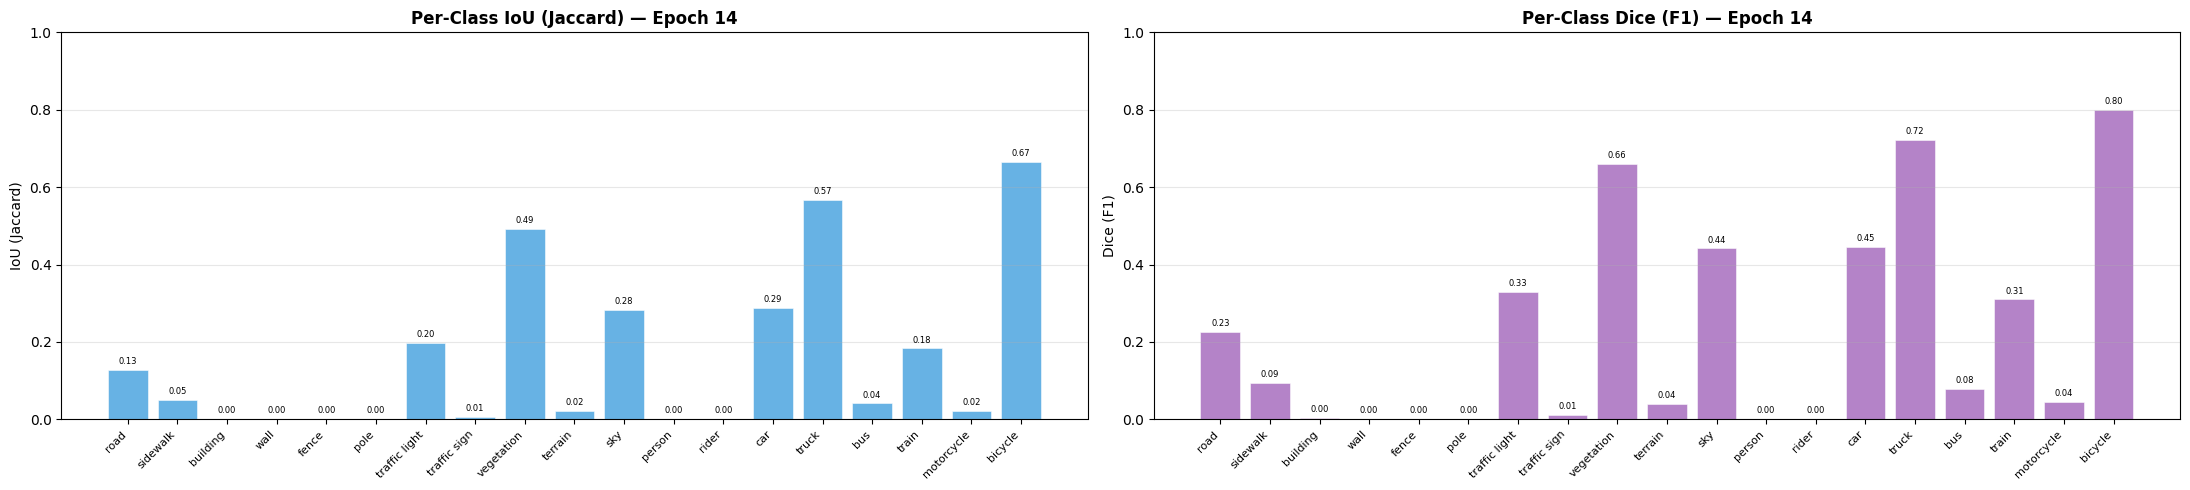


  EPOCH 15/50   lr=8.19e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

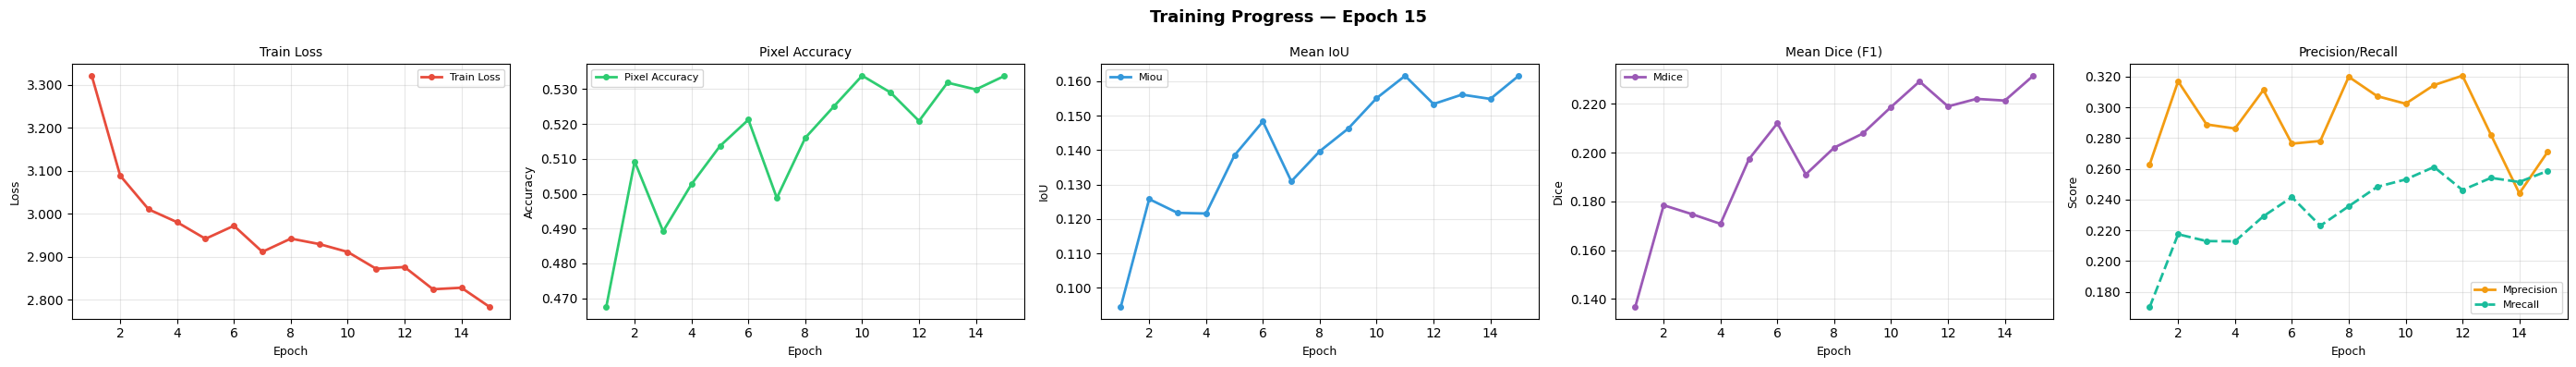

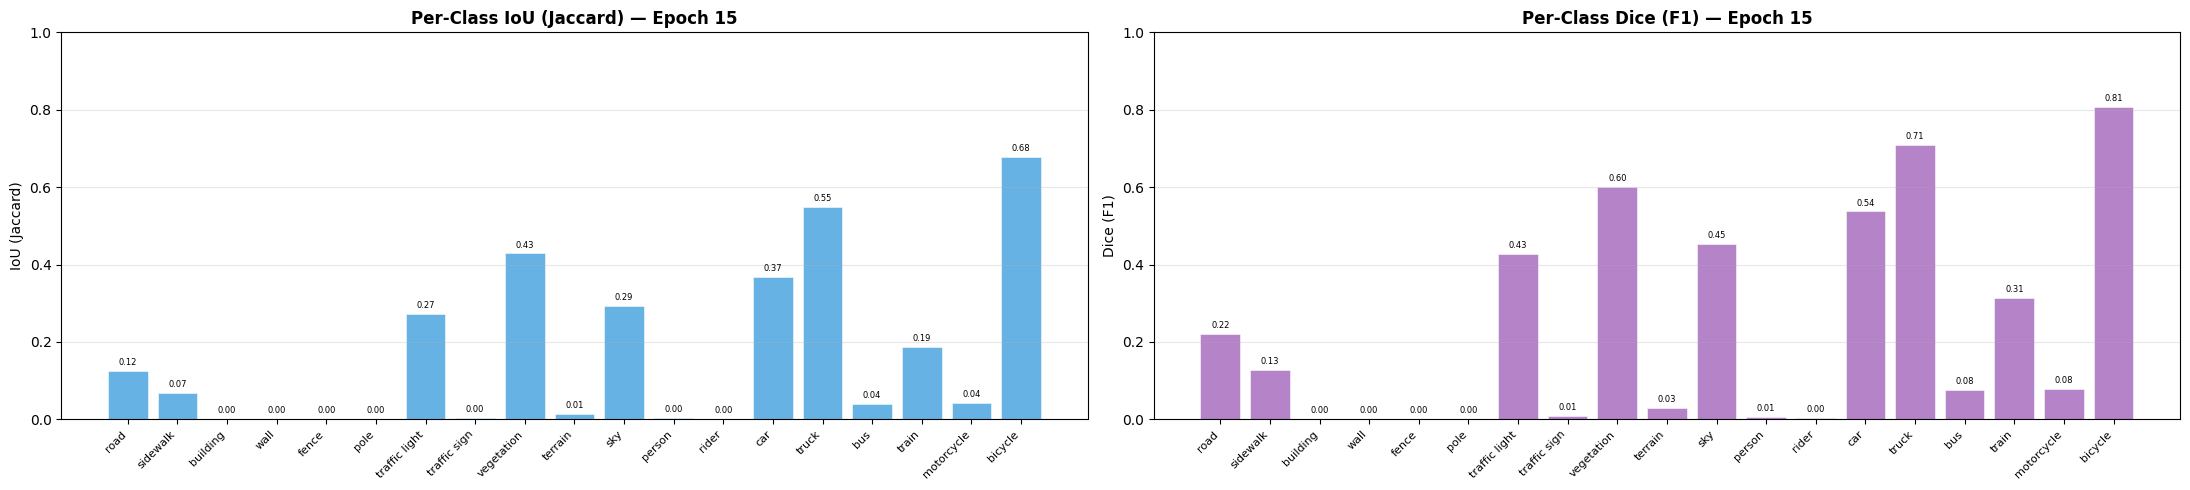


  EPOCH 16/50   lr=7.94e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

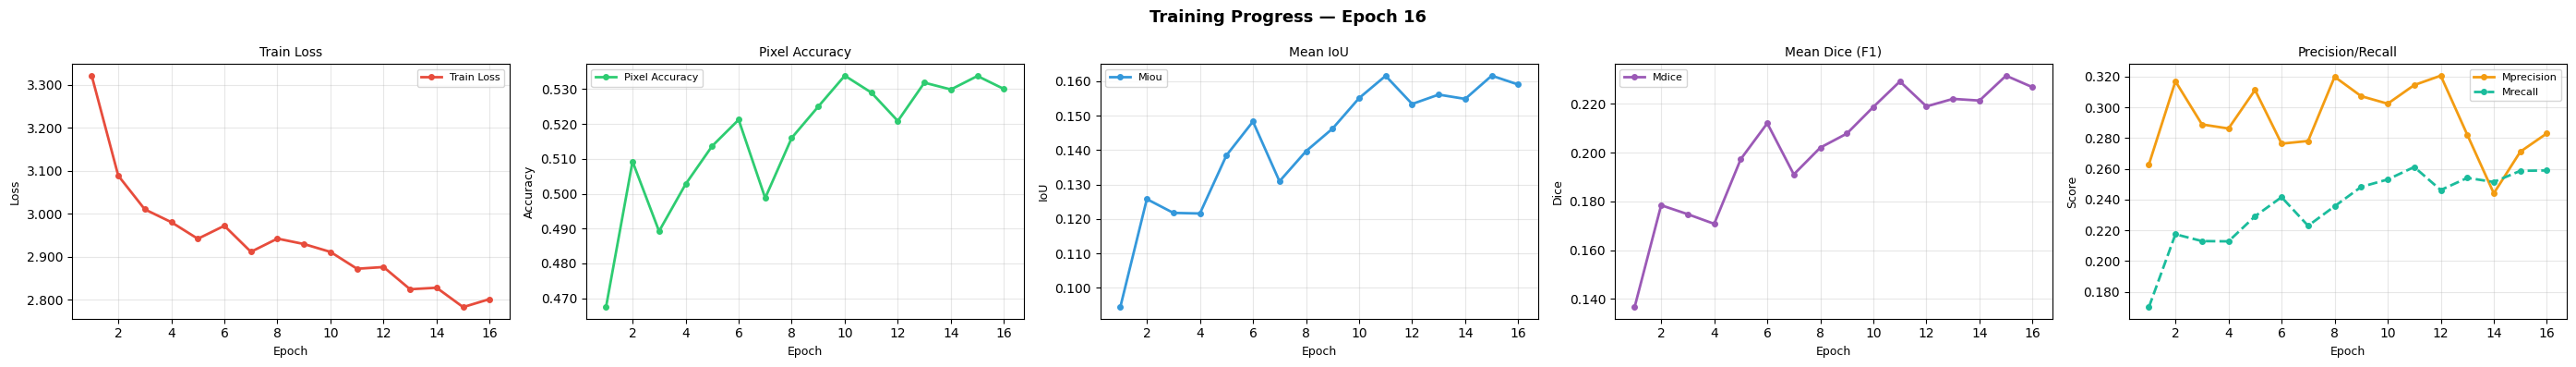

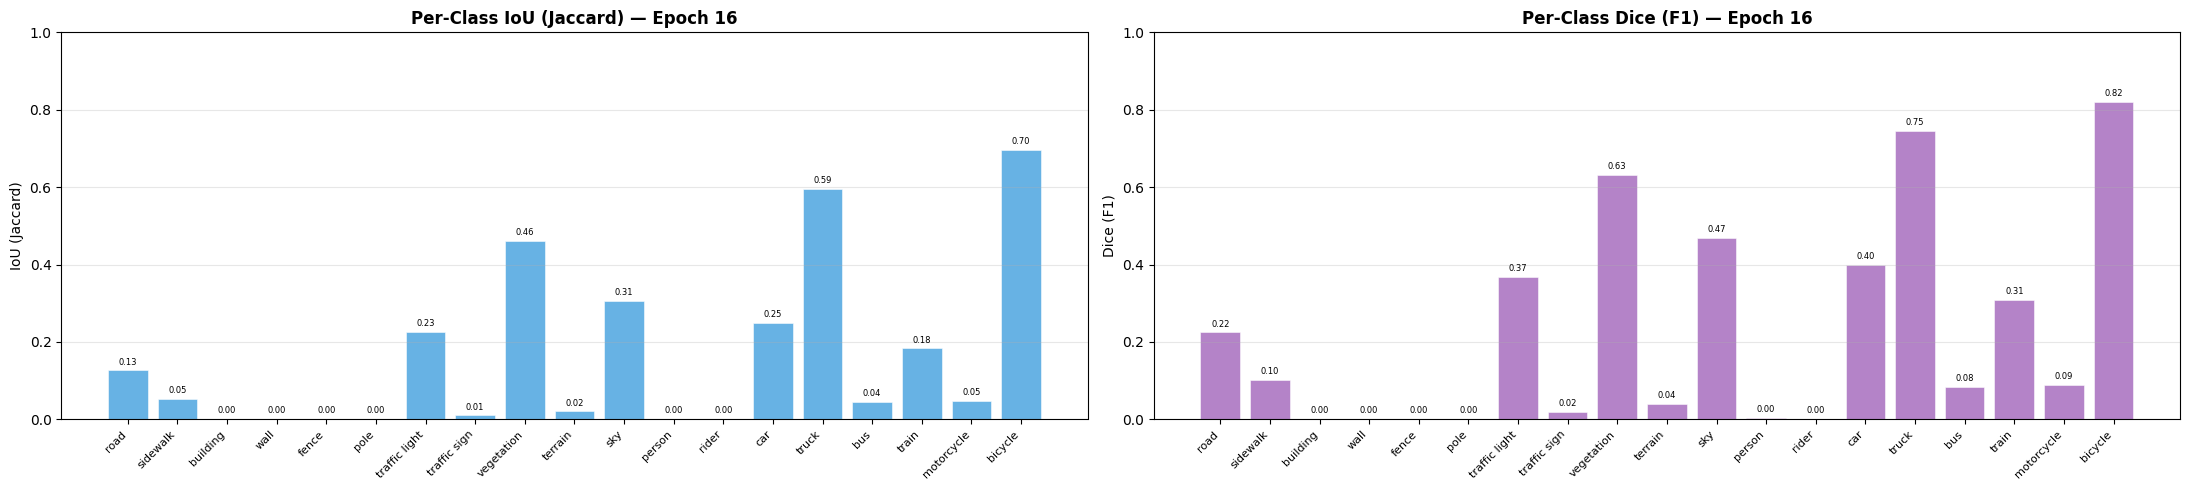


  EPOCH 17/50   lr=7.68e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

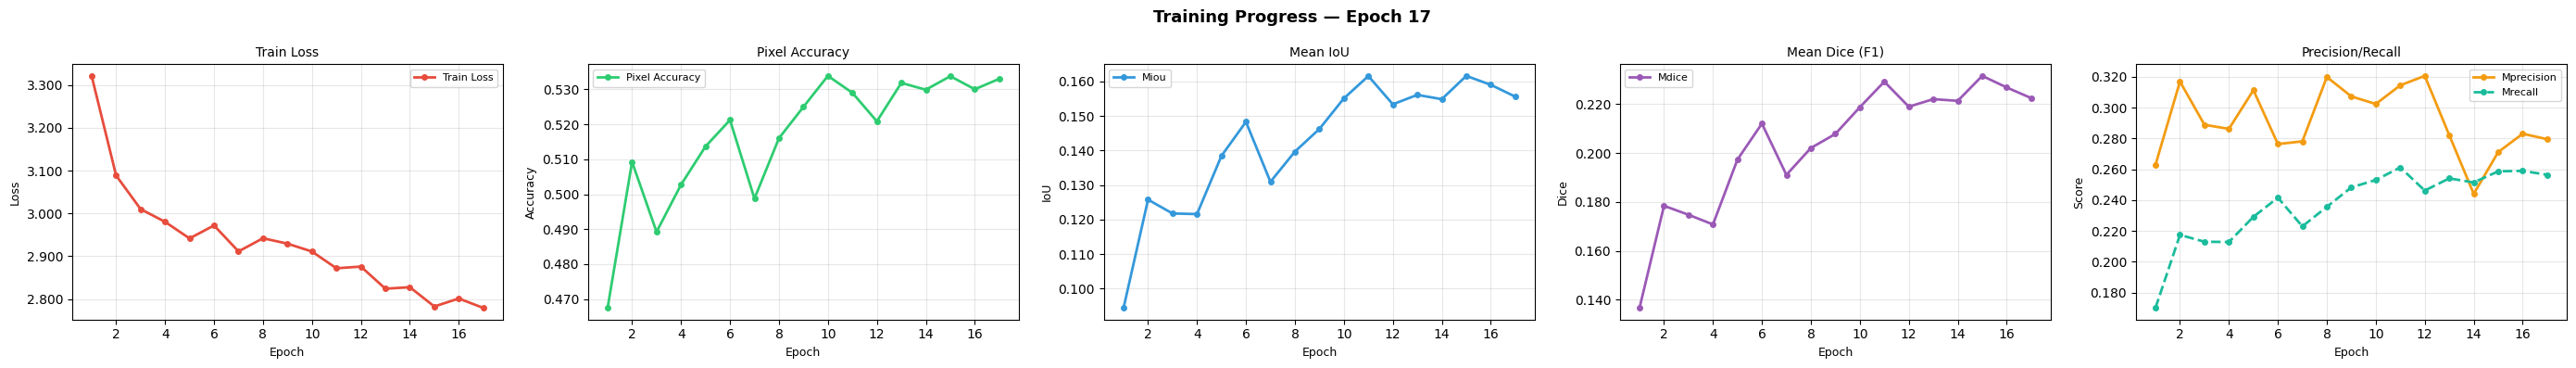

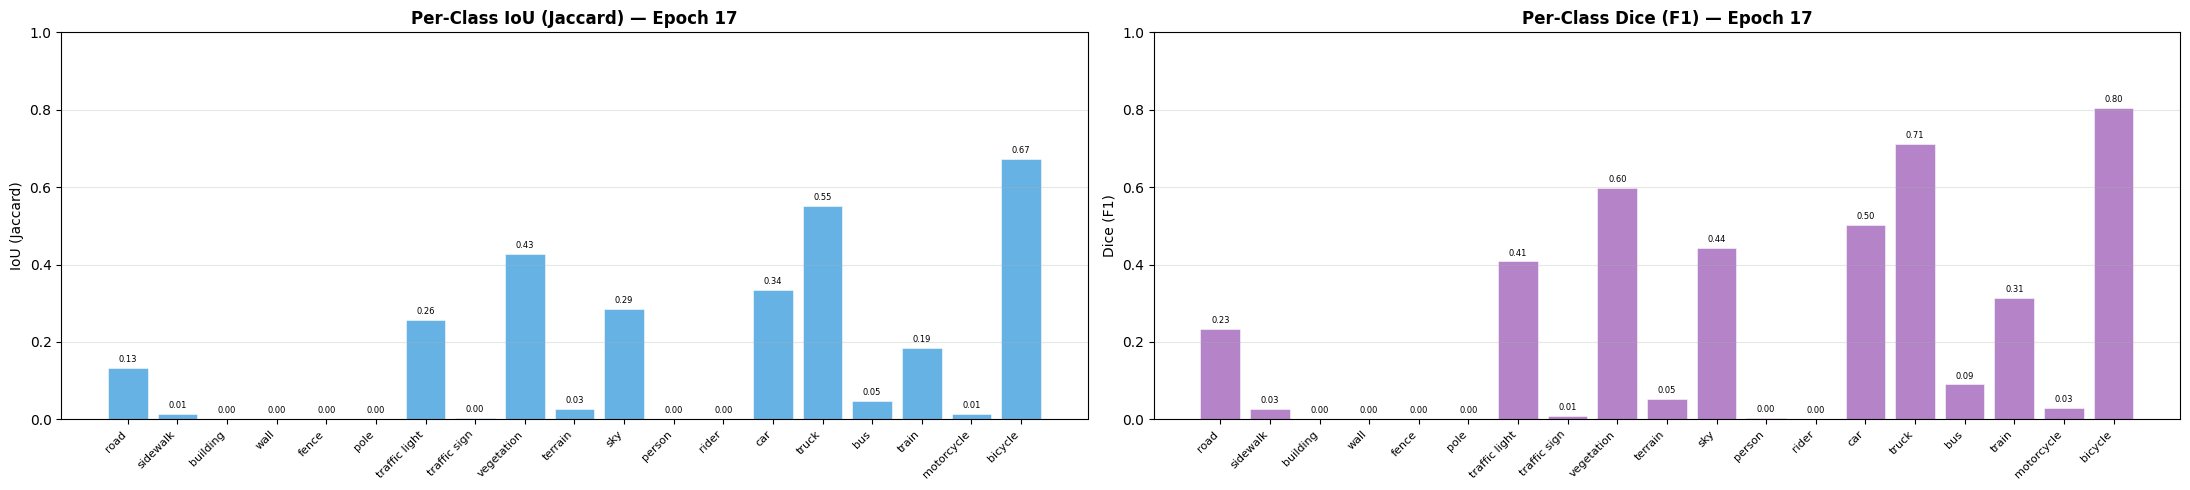


  EPOCH 18/50   lr=7.41e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

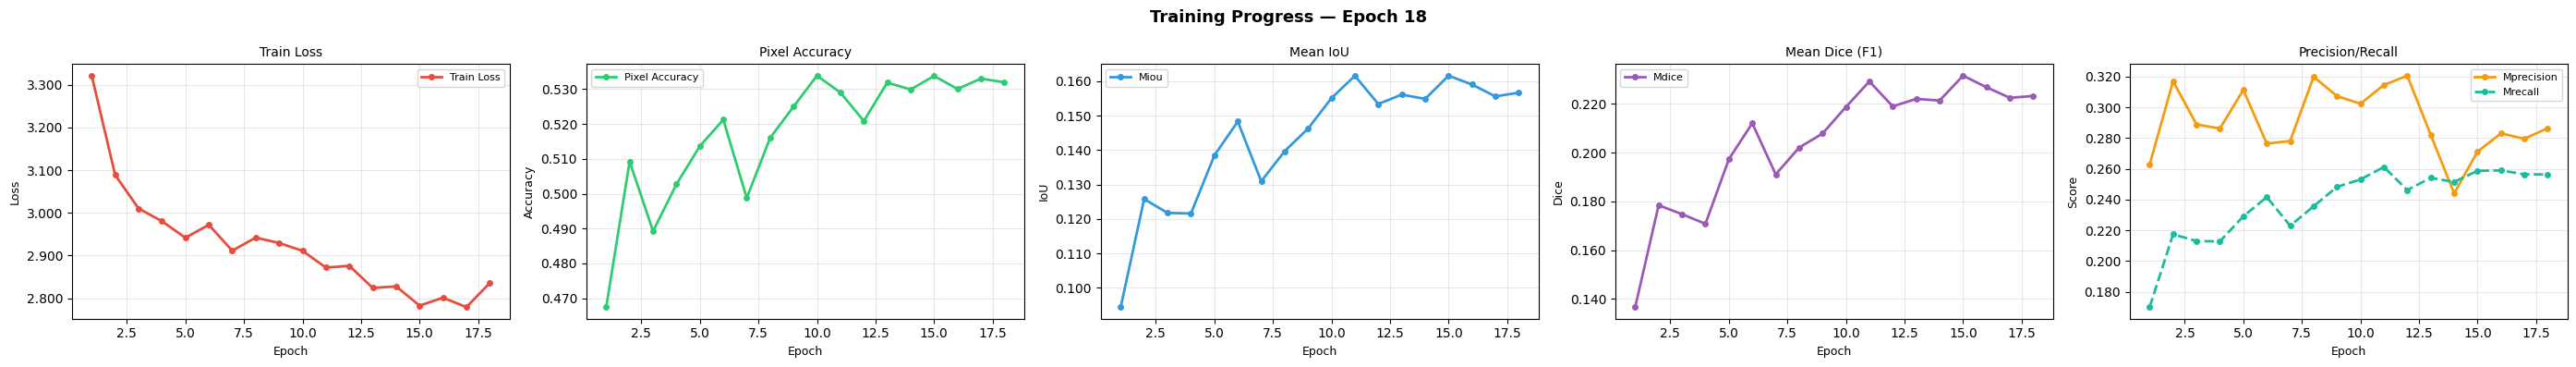

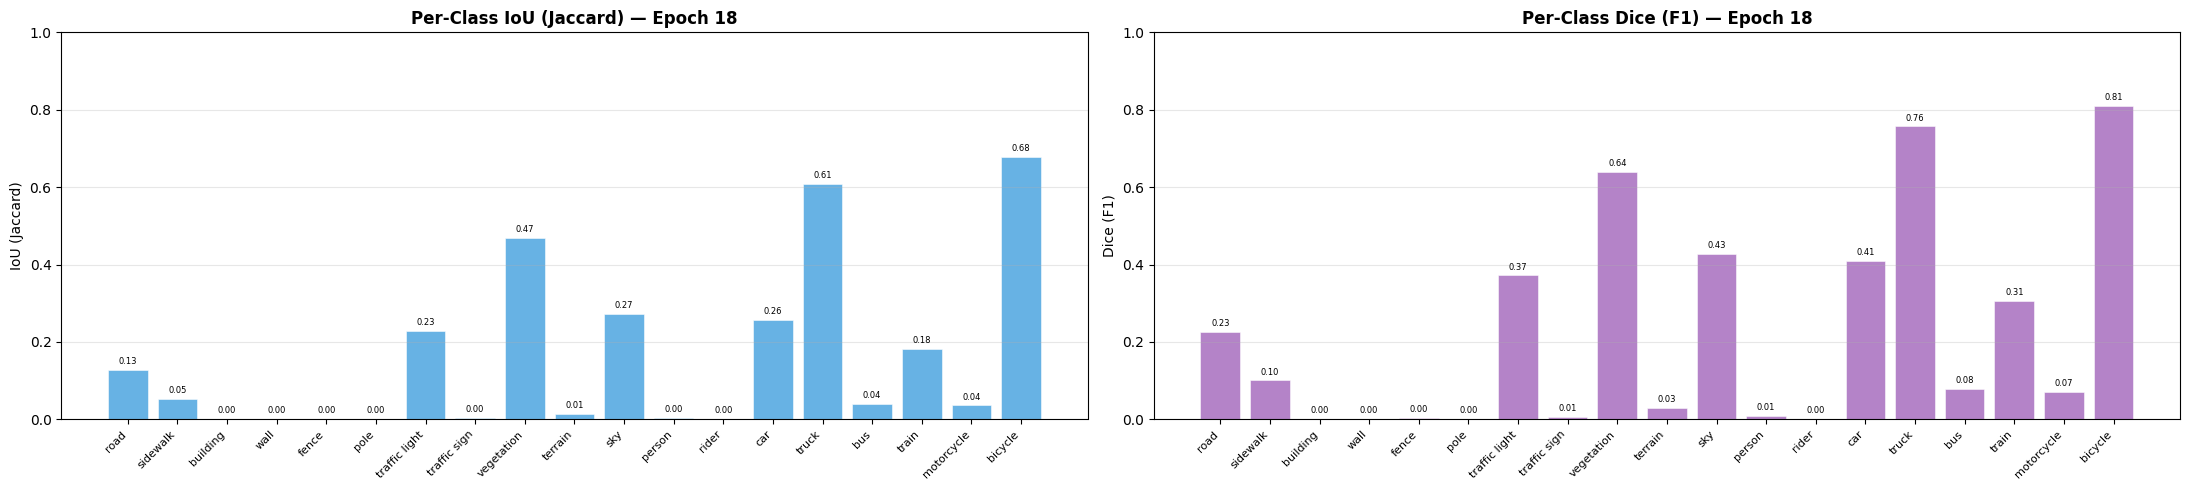


  EPOCH 19/50   lr=7.13e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

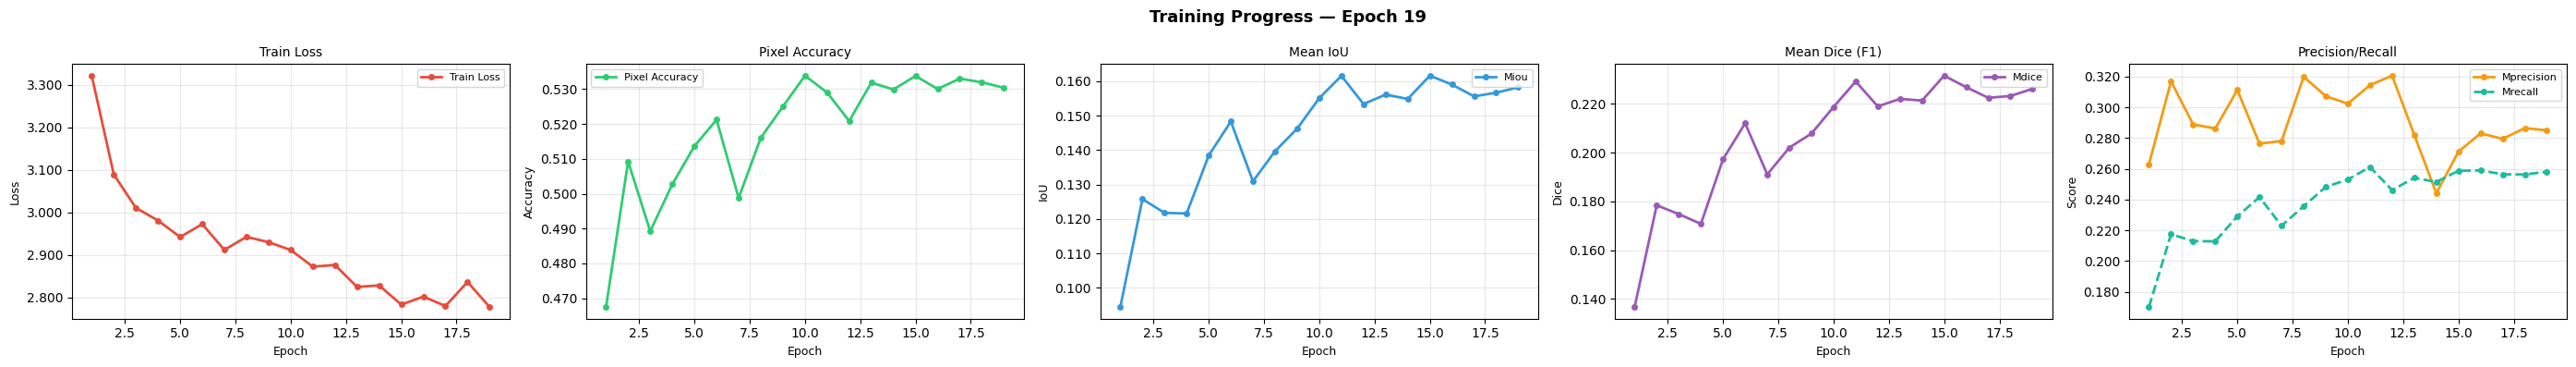

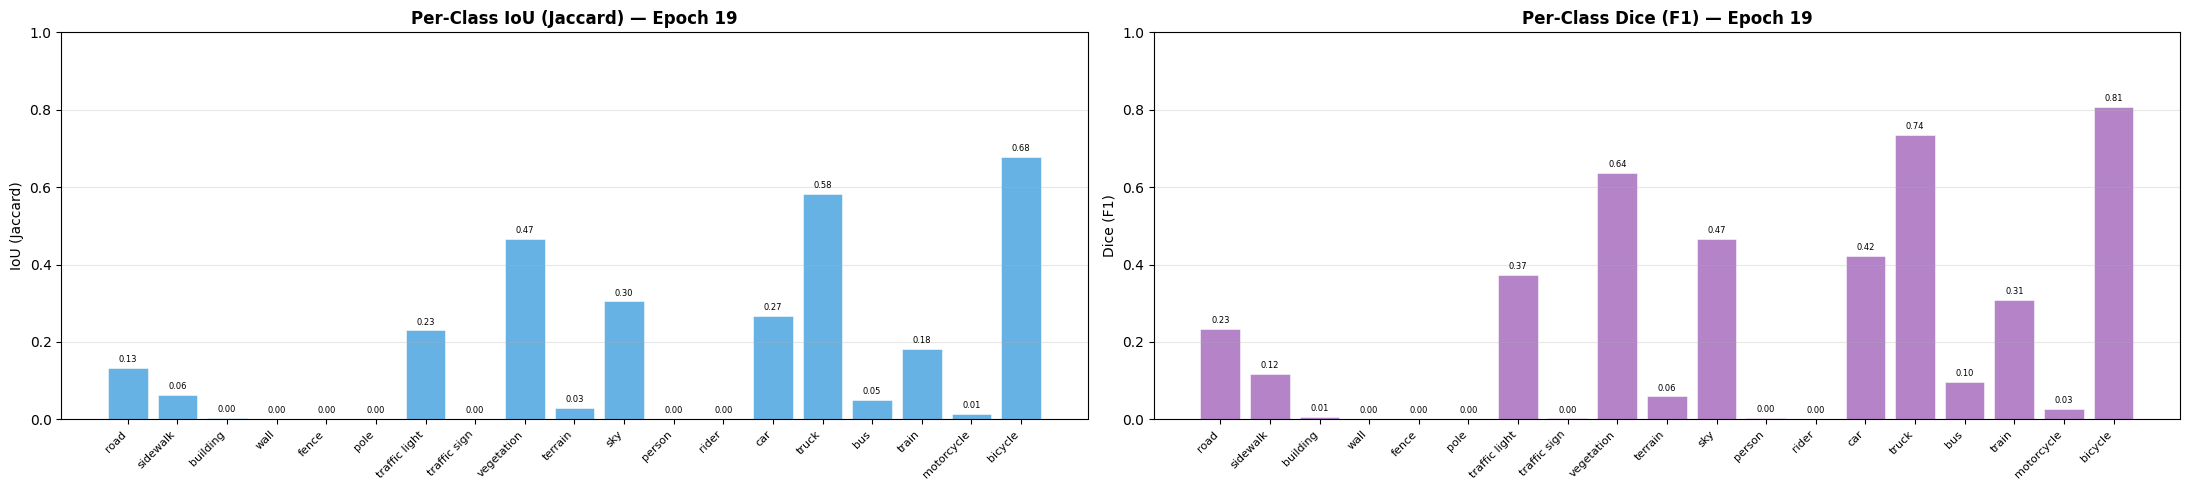


  EPOCH 20/50   lr=6.84e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

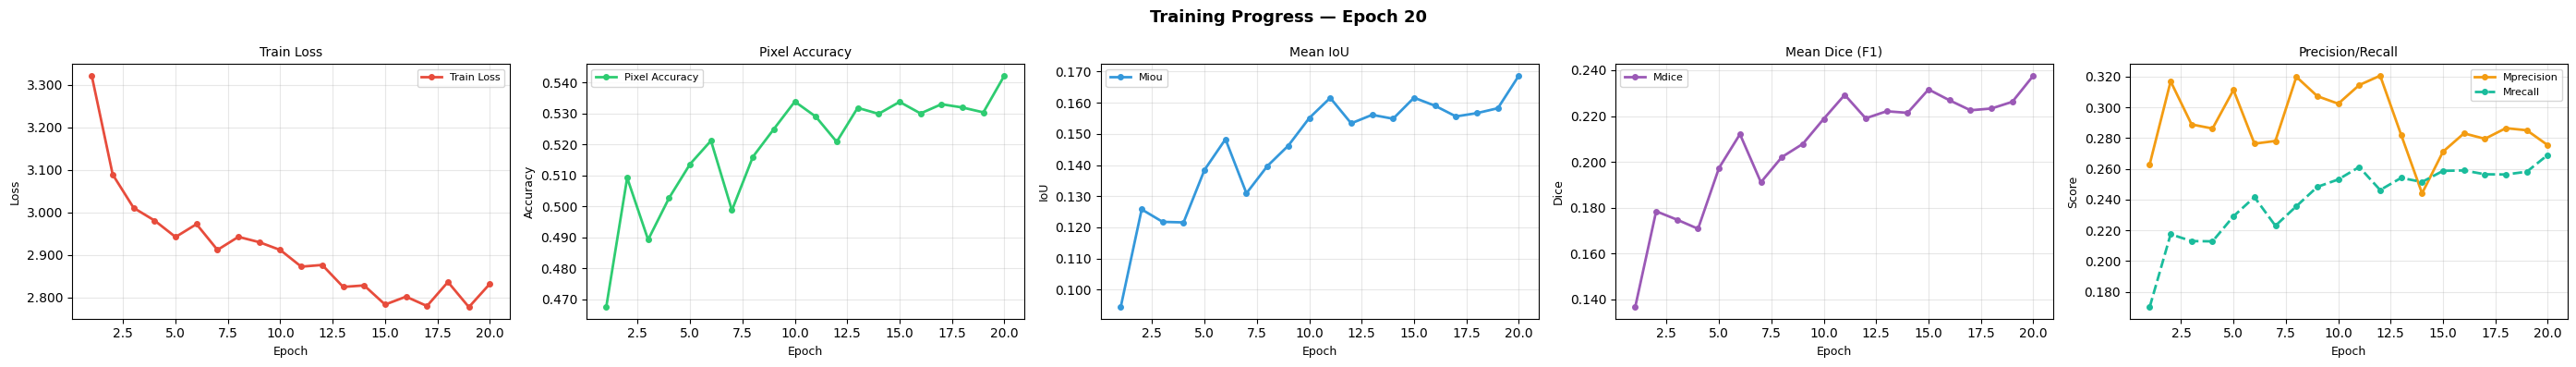

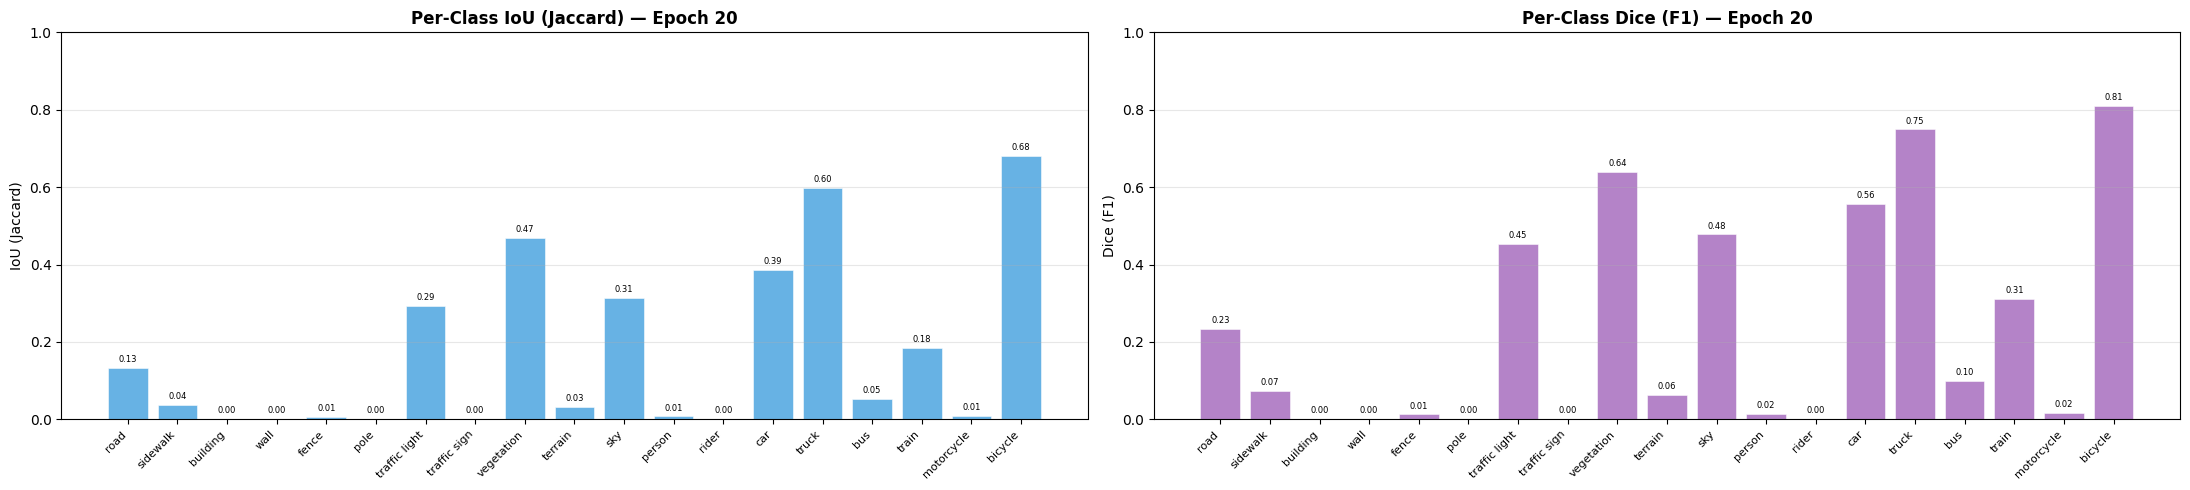


  EPOCH 21/50   lr=6.55e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

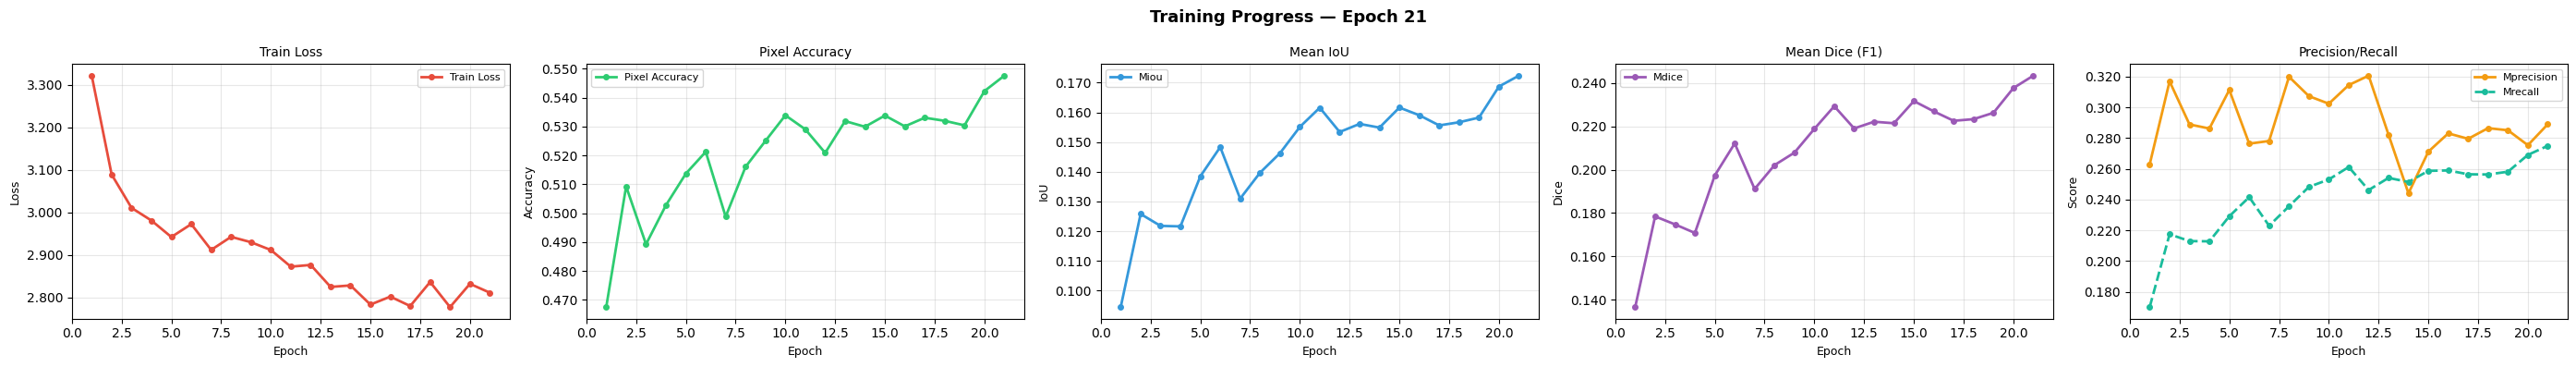

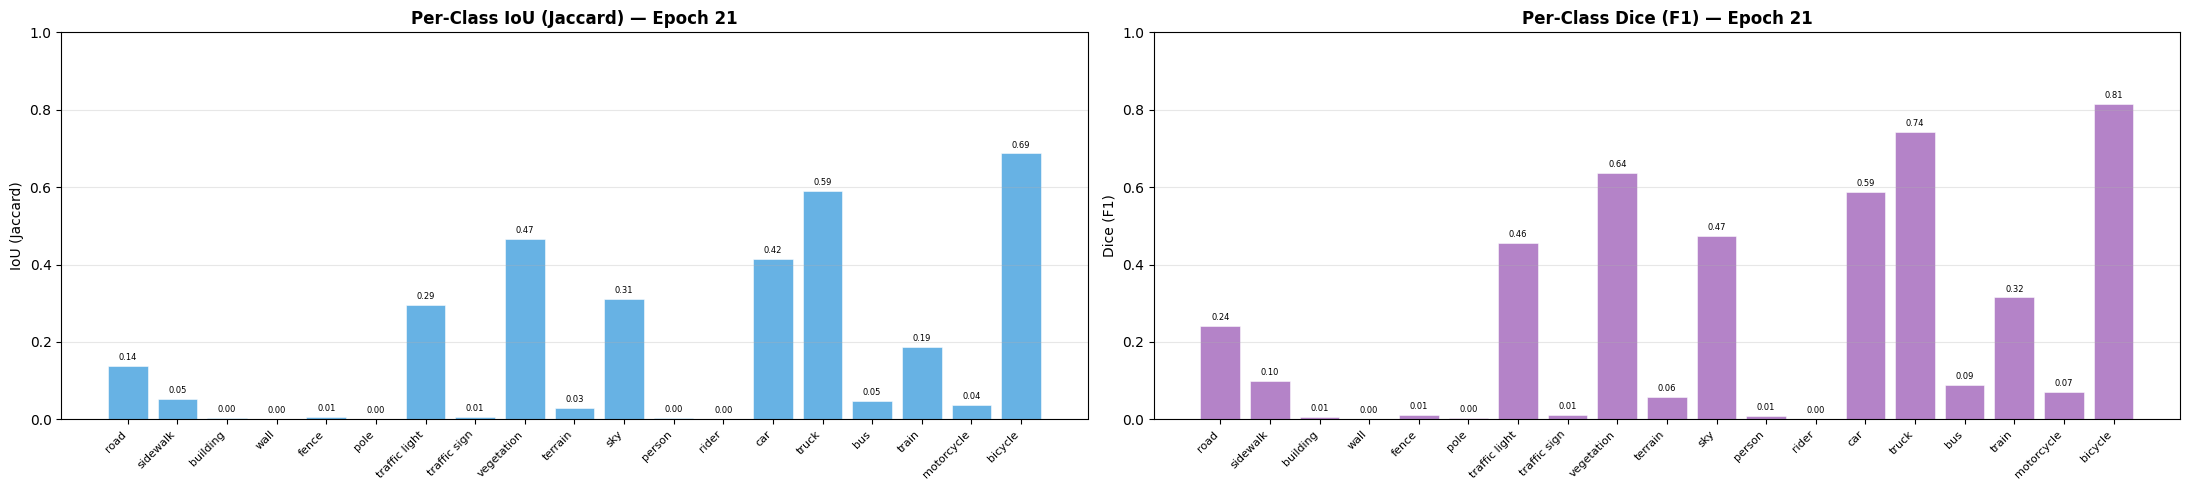


  EPOCH 22/50   lr=6.24e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

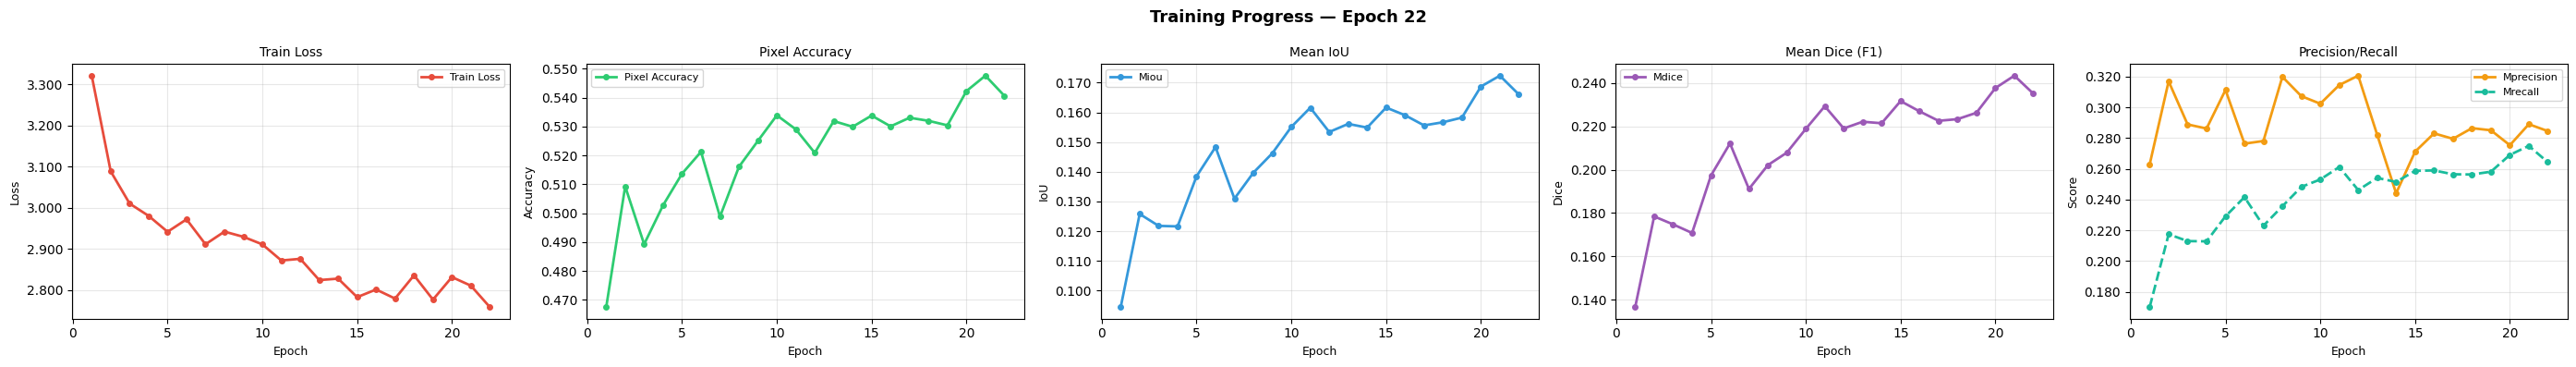

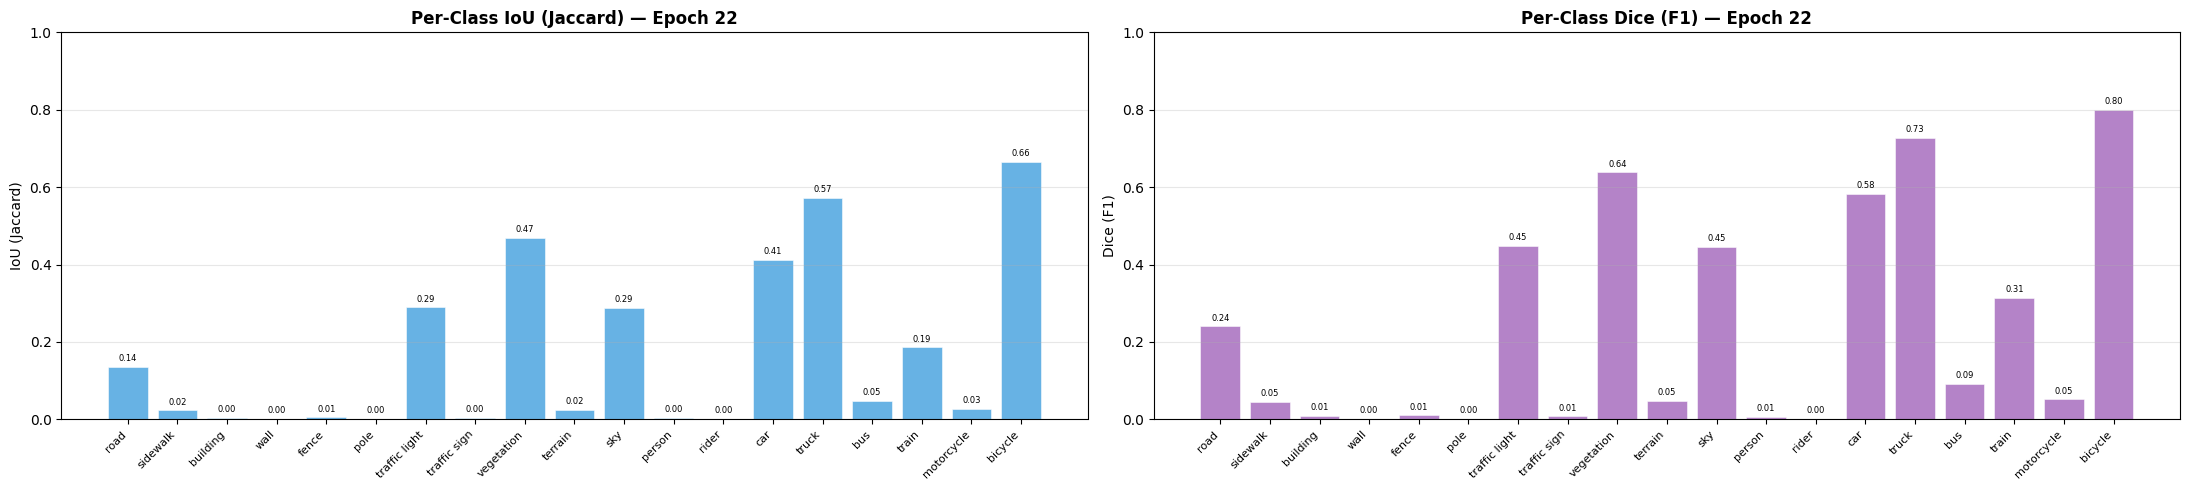


  EPOCH 23/50   lr=5.94e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

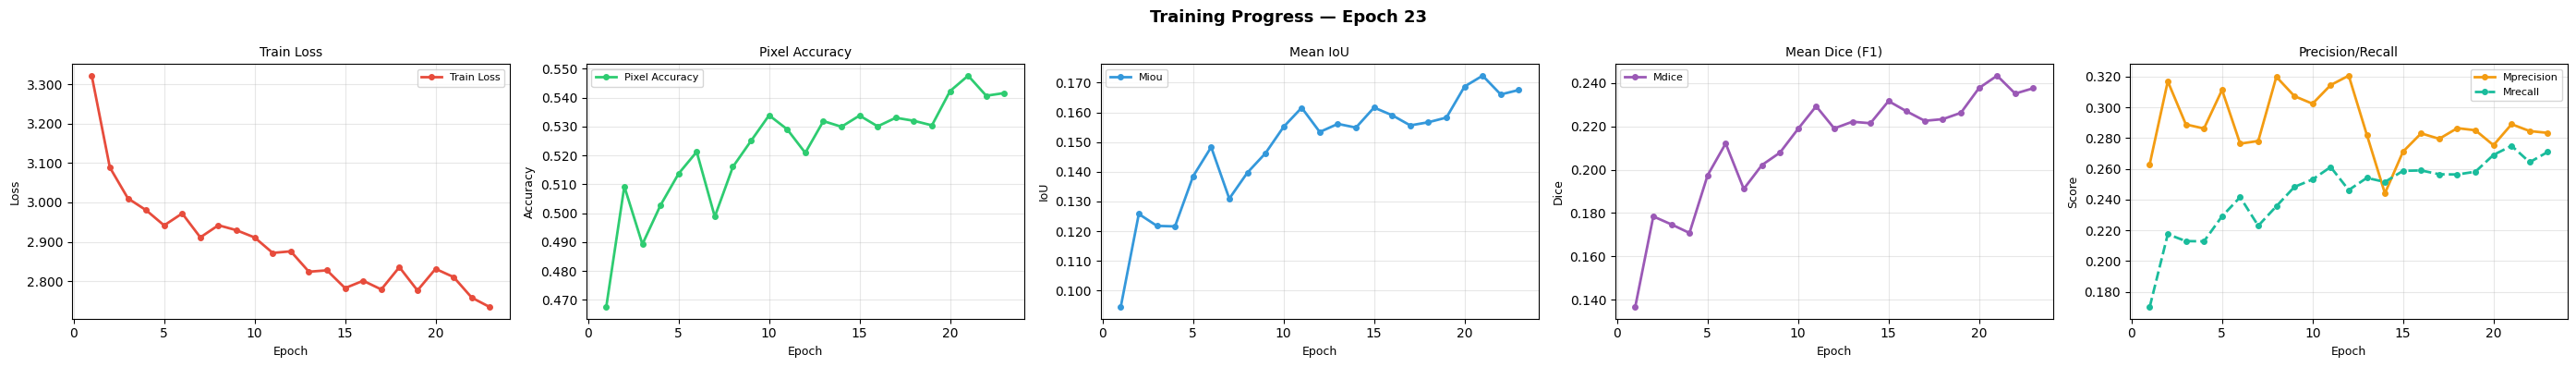

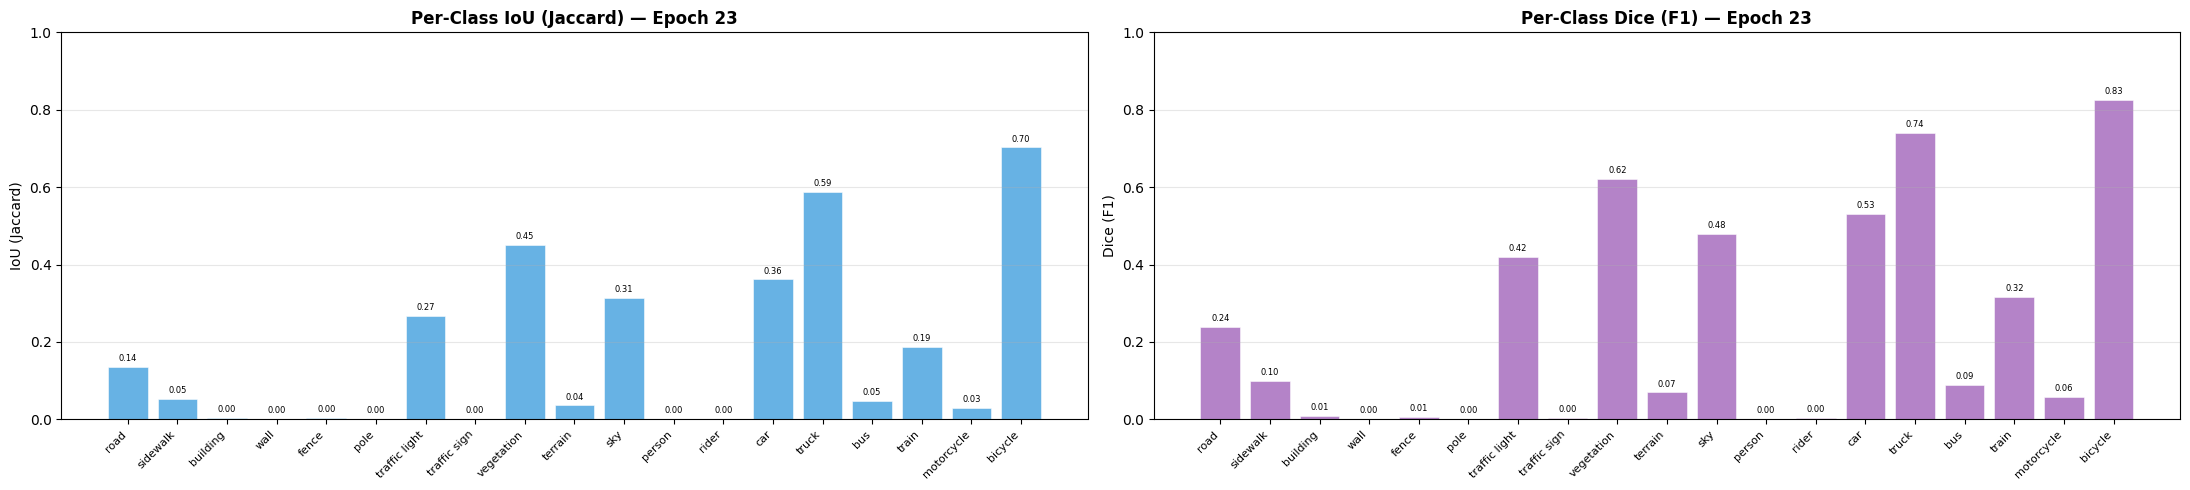


  EPOCH 24/50   lr=5.63e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

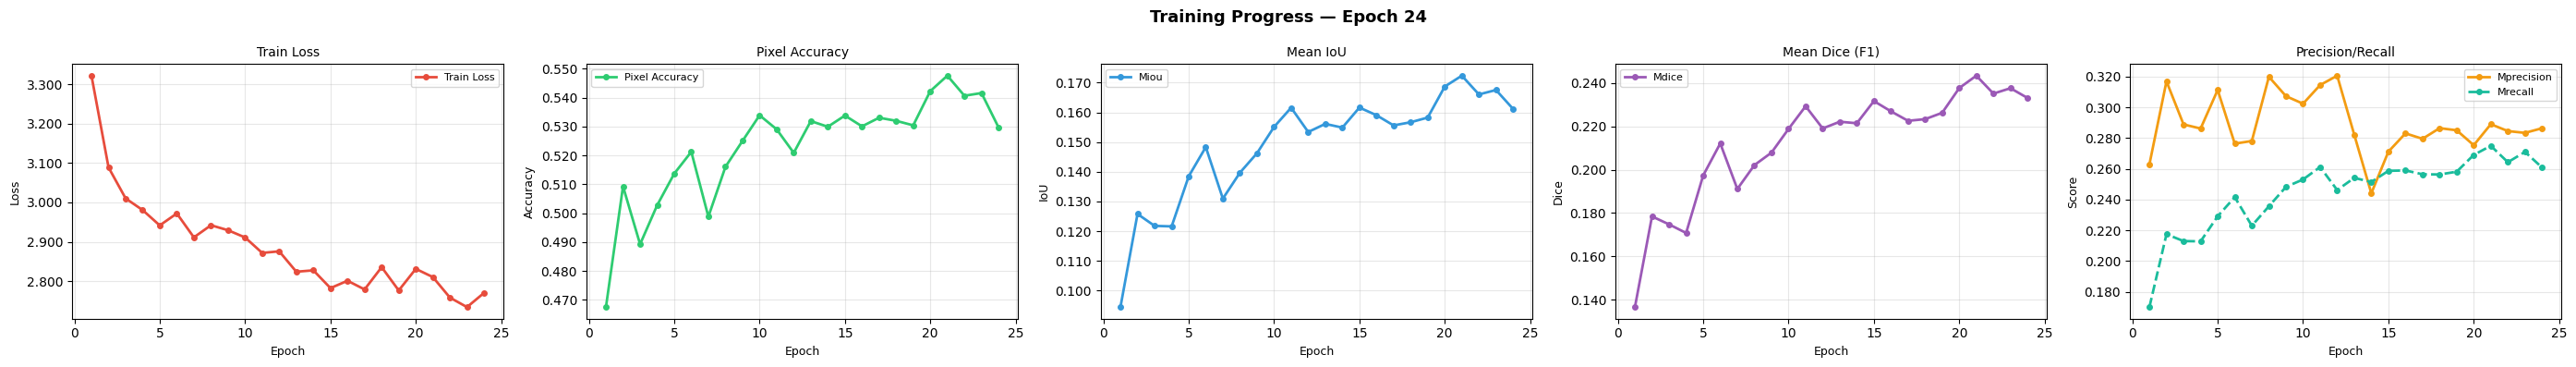

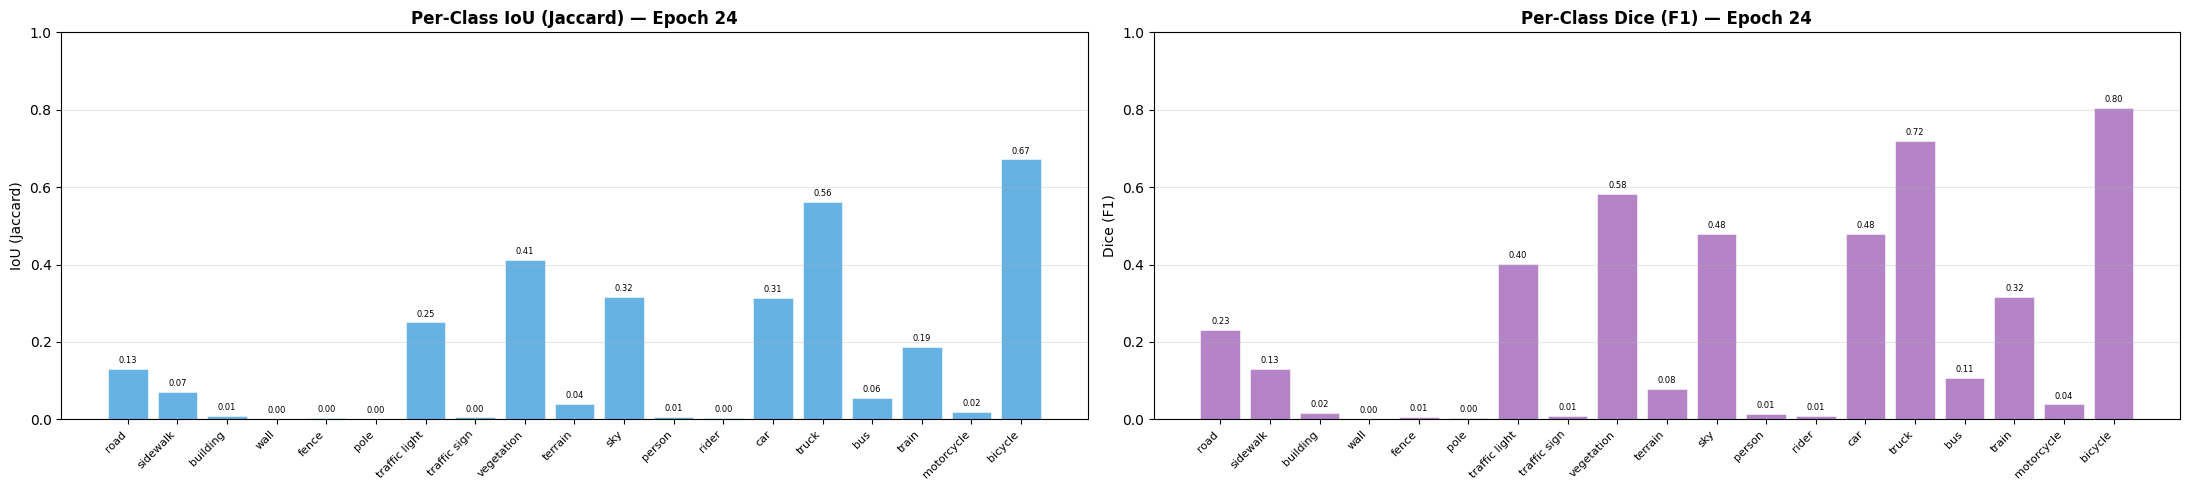


  EPOCH 25/50   lr=5.31e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

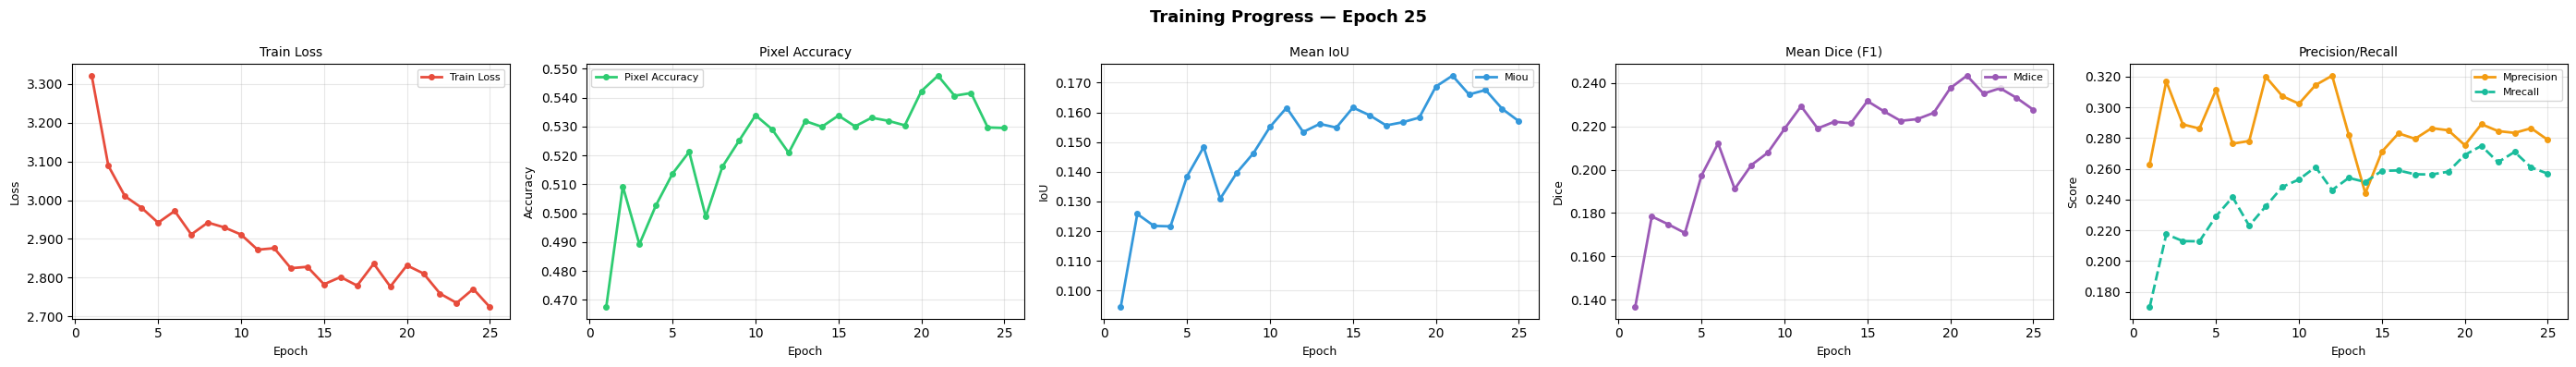

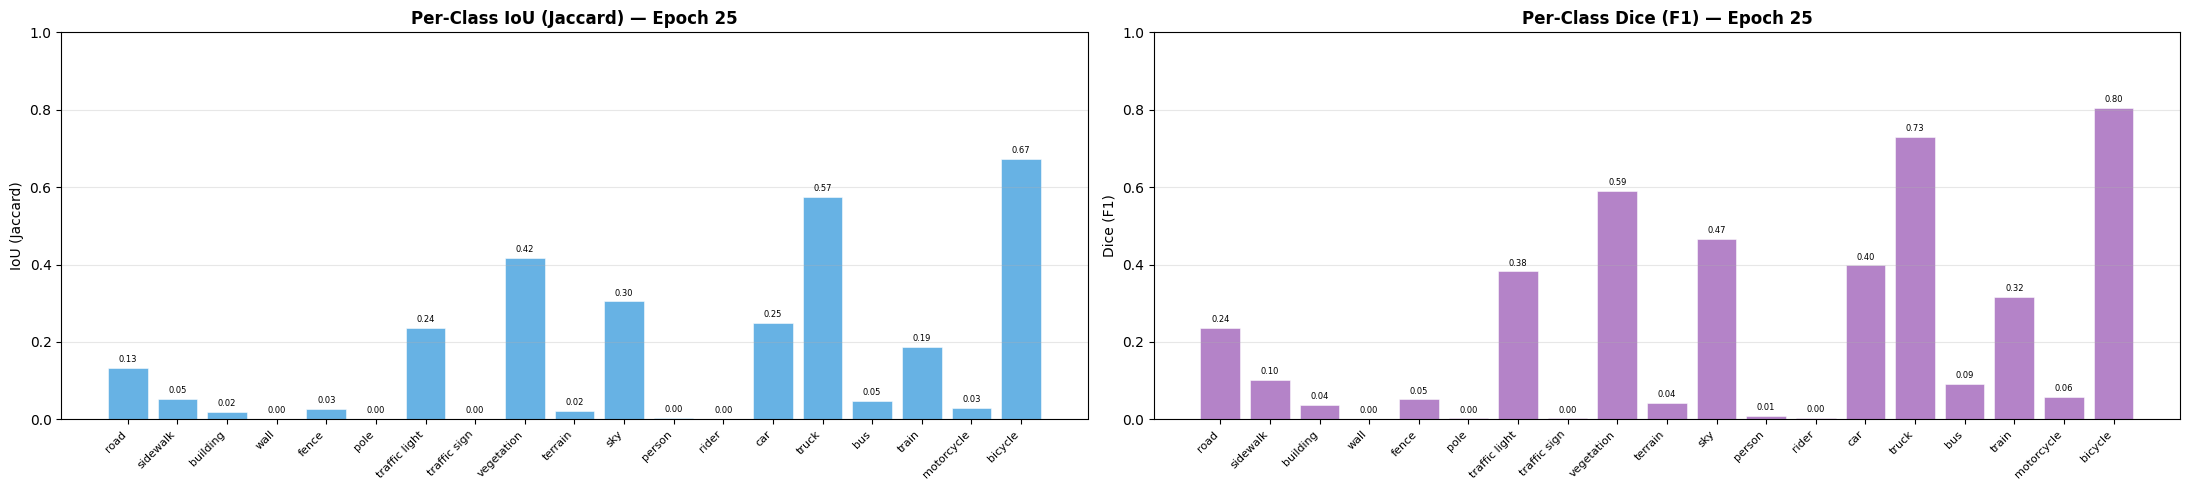


  EPOCH 26/50   lr=5.00e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

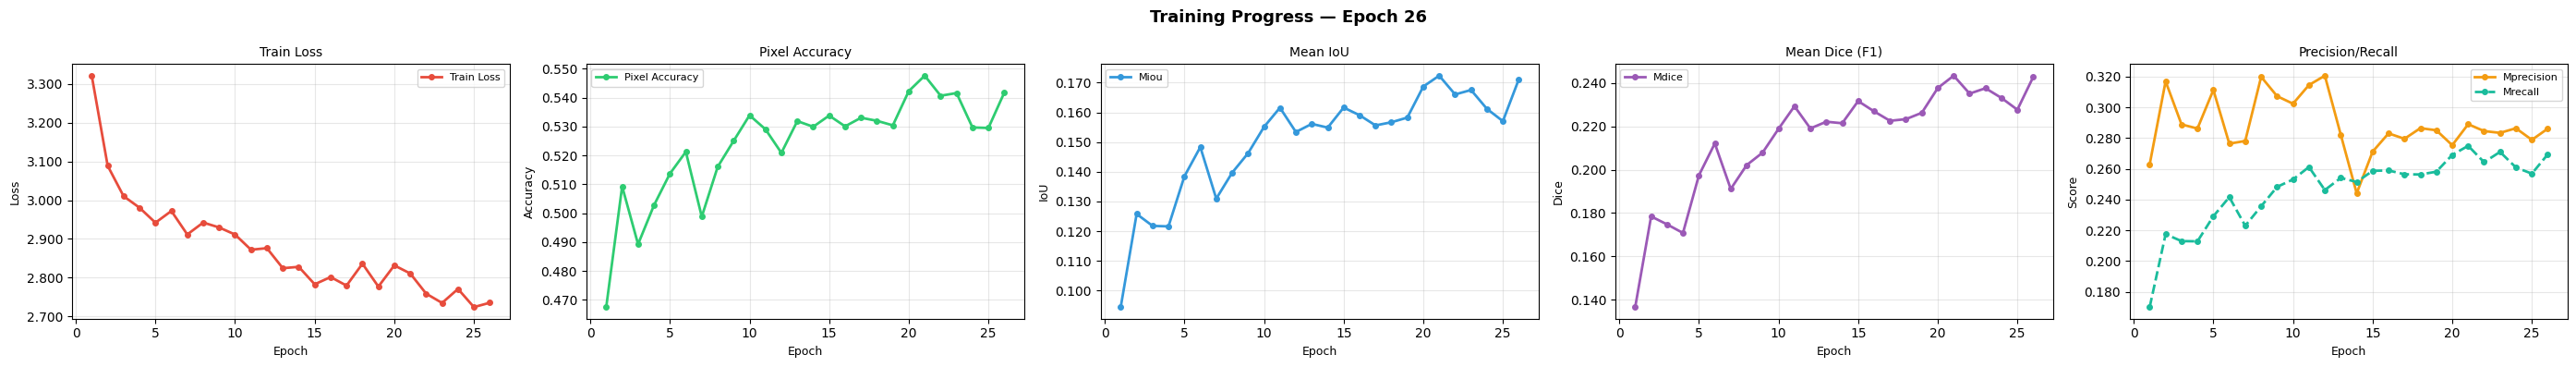

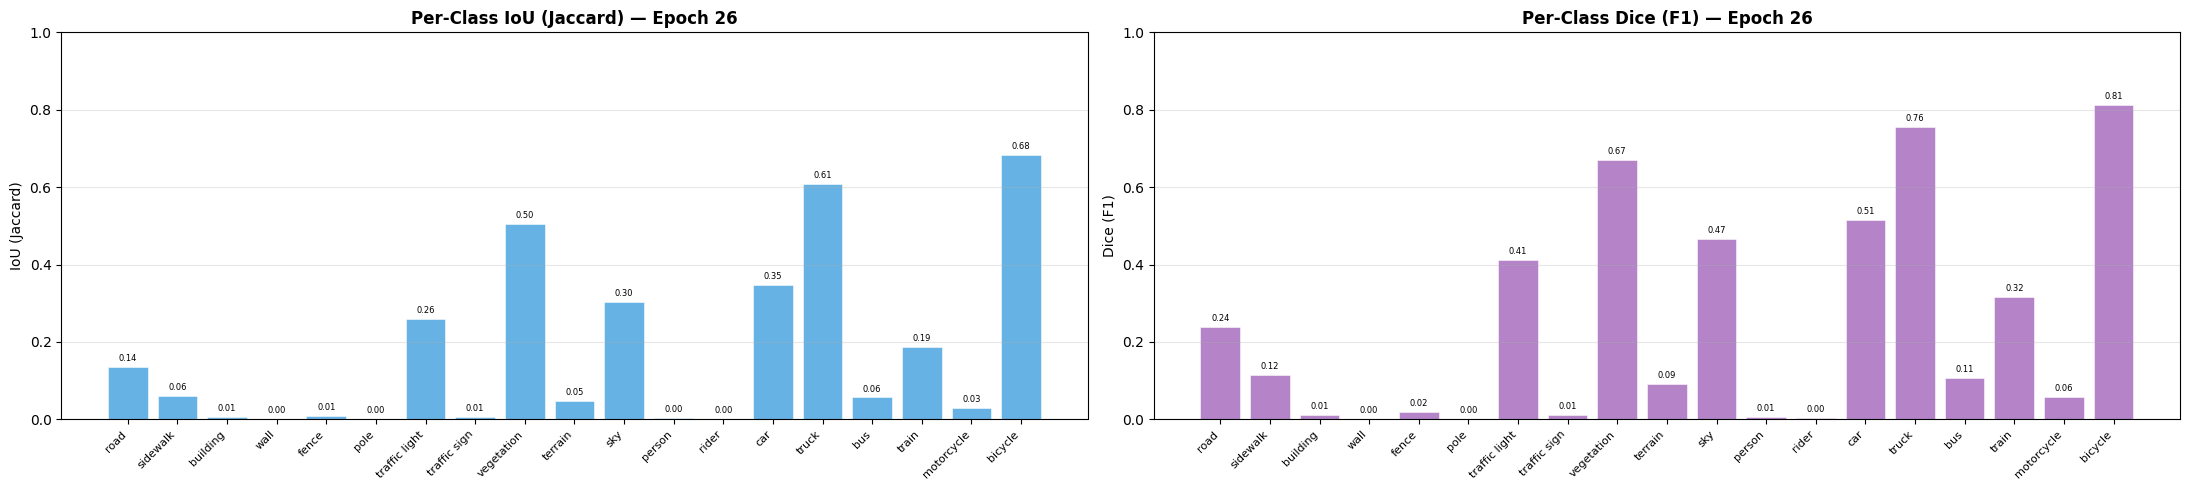


  EPOCH 27/50   lr=4.69e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

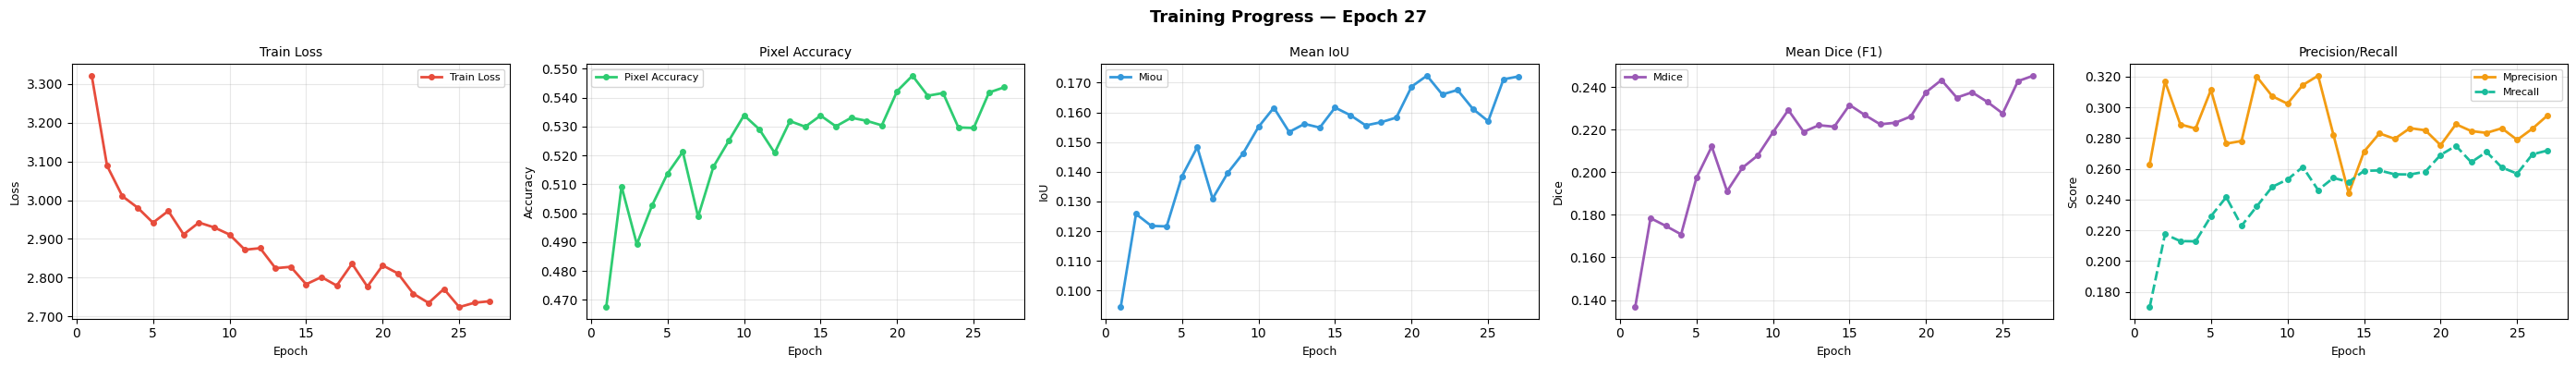

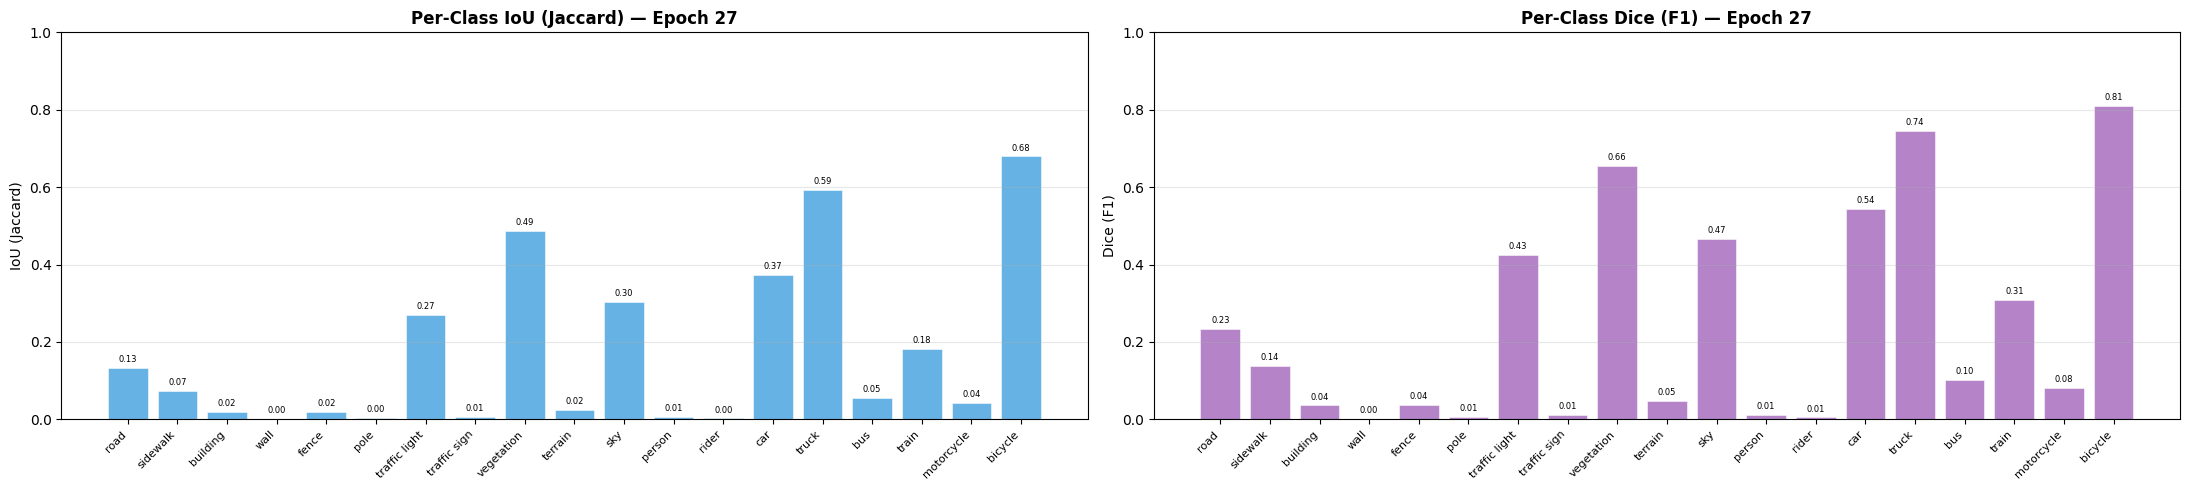


  EPOCH 28/50   lr=4.37e-05


  [Train]:   0%|          | 0/372 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask = Image.fromarray(mask_indices.astype(np.uint8), mode='L')
  [Val]  :   0%|          | 0/63 [00:00<?, ?it/s]/tmp/ipykernel_23/3897530546.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be remove

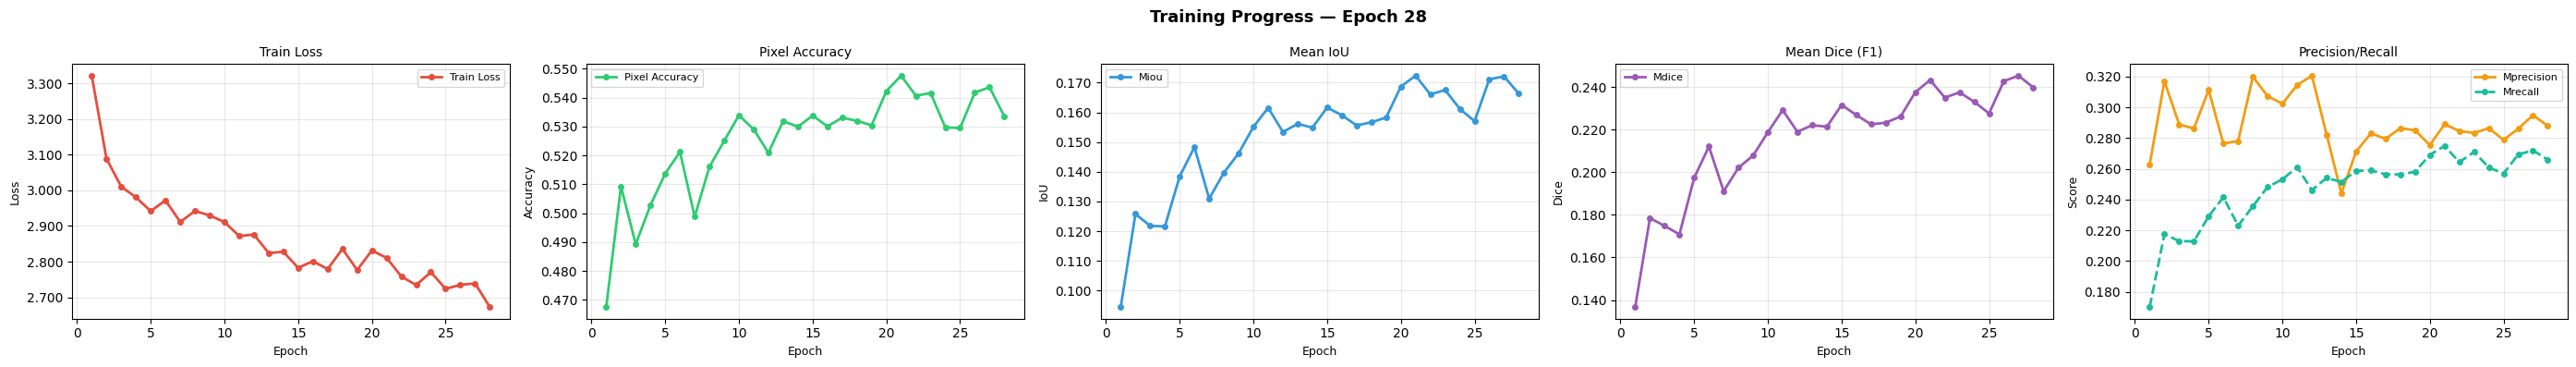

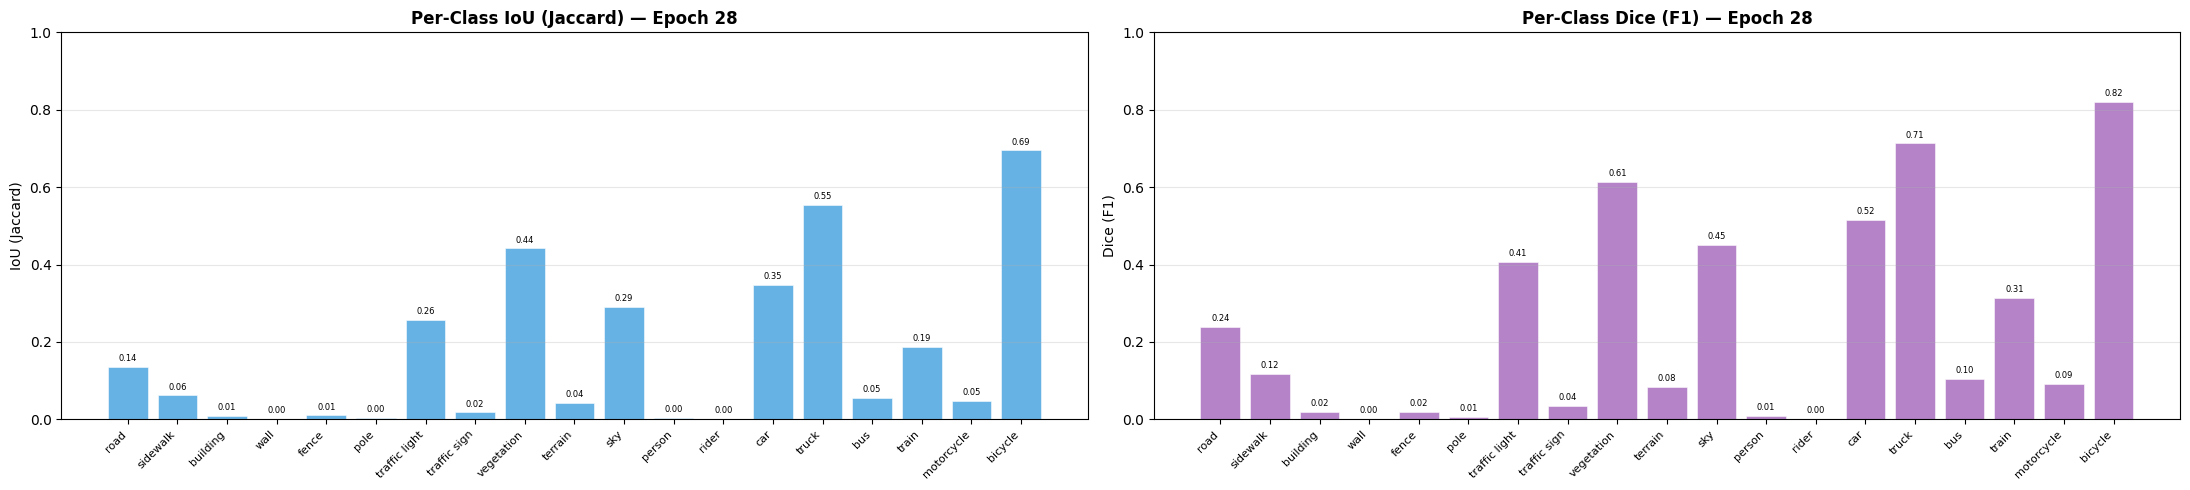

In [12]:
trained_model = run_training_loop(
    data_root  = DATA_ROOT,
    epochs     = 50,
    batch_size = 8,
    img_size   = IMG_SIZE
)